# STEEL PLATE DEFECT PREDICTION

#### Dataset Description
The dataset was obtained from Steel Plates Faults dataset from UCI. Feature distributions are close to, but not exactly the same, as the original.

#### Evaluation
Submissions are evaluated using area under the ROC curve using the predicted probabilities and the ground truth targets.

To calculate the final score, AUC is calculated for each of the 7 defect categories and then averaged. In other words, the score is the average of the individual AUC of each predicted column.

#### Additional Information
Type of dependent variables (7 Types of Steel Plates Faults):
1.Pastry
2.Z_Scratch
3.K_Scatch
4.Stains
5.Dirtiness
6.Bumps
7.Other_Faults

SOURCE: https://www.kaggle.com/competitions/playground-series-s4e3/data

---
## LIBRARIES IMPORT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import IsolationForest

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pointbiserialr, pearsonr, spearmanr

from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
from sklearn.preprocessing import label_binarize
from lightgbm import LGBMClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define function for use in outliers removal, the method that we'll use is IQR based
def outlier_fx(data, parameter):
    q1 = data[parameter].quantile(0.25)
    q3 = data[parameter].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    clean = data[(data[parameter] >= lower) & (data[parameter] <= upper)]
    return clean

In [ ]:
def outlier_fx_grouped(data, parameter, groupby_col):
    frames = []
    for group, subset in data.groupby(groupby_col):
        q1 = subset[parameter].quantile(0.25)
        q3 = subset[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        subset_cleaned = subset[(subset[parameter] >= lower) & (subset[parameter] <= upper)]
        frames.append(subset_cleaned)
    return pd.concat(frames)

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/bootcamp batch9/Defect clf/train_defect.csv')
data

,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,0,584,590,909972,909977,16,8,5,2274,113,...,-0.5000,-0.0104,0.1417,0,0,0,1,0,0,0
1,1,808,816,728350,728372,433,20,54,44478,70,...,0.7419,-0.2997,0.9491,0,0,0,0,0,0,1
2,2,39,192,2212076,2212144,11388,705,420,1311391,29,...,-0.0105,-0.0944,1.0000,0,0,1,0,0,0,0
3,3,781,789,3353146,3353173,210,16,29,3202,114,...,0.6667,-0.0402,0.4025,0,0,1,0,0,0,0
4,4,1540,1560,618457,618502,521,72,67,48231,82,...,0.9158,-0.2455,0.9998,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19214,19214,749,757,143210,143219,17,4,4,2193,122,...,-0.1429,0.0044,0.2901,0,0,0,1,0,0,0
19215,19215,723,735,2488529,2488541,231,17,26,27135,104,...,0.7222,-0.0989,0.5378,0,0,0,0,0,0,1
19216,19216,6,31,1578055,1578129,780,114,98,71112,41,...,0.7719,-0.4283,0.9997,1,0,0,0,0,0,0
19217,19217,9,18,1713172,1713184,126,13,26,14808,88,...,0.9610,-0.1162,0.3509,0,0,0,0,0,0,1


---
## EXPLORATORY DATA ANALYSIS

In [ ]:
data.isnull().sum()

,0
id,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0


In [ ]:
data.describe()

,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,19219.000000,19219.000000,19219.000000,1.921900e+04,1.921900e+04,19219.000000,19219.000000,19219.000000,1.921900e+04,19219.000000,...,19219.000000,19219.000000,19219.000000,19219.000000,19219.000000,19219.000000,19219.000000,19219.000000,19219.000000,19219.000000
mean,9609.000000,709.854675,753.857641,1.849756e+06,1.846605e+06,1683.987616,95.654665,64.124096,1.918467e+05,84.808419,...,0.102742,-0.138382,0.571902,0.076279,0.059837,0.178573,0.029554,0.025235,0.247828,0.341225
std,5548.191747,531.544189,499.836603,1.903554e+06,1.896295e+06,3730.319865,177.821382,101.054178,4.420247e+05,28.800344,...,0.487681,0.120344,0.332219,0.265450,0.237190,0.383005,0.169358,0.156844,0.431762,0.474133
min,0.000000,0.000000,4.000000,6.712000e+03,6.724000e+03,6.000000,2.000000,1.000000,2.500000e+02,0.000000,...,-0.988400,-0.885000,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4804.500000,49.000000,214.000000,6.574680e+05,6.575020e+05,89.000000,15.000000,14.000000,9.848000e+03,70.000000,...,-0.272700,-0.192500,0.253200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9609.000000,777.000000,796.000000,1.398169e+06,1.398179e+06,168.000000,25.000000,23.000000,1.823800e+04,90.000000,...,0.111100,-0.142600,0.472900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14413.500000,1152.000000,1165.000000,2.368032e+06,2.362511e+06,653.000000,64.000000,61.000000,6.797800e+04,105.000000,...,0.529400,-0.084000,0.999400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,19218.000000,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,7553.000000,903.000000,1.159141e+07,196.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19219 entries, 0 to 19218
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     19219 non-null  int64  
 1   X_Minimum              19219 non-null  int64  
 2   X_Maximum              19219 non-null  int64  
 3   Y_Minimum              19219 non-null  int64  
 4   Y_Maximum              19219 non-null  int64  
 5   Pixels_Areas           19219 non-null  int64  
 6   X_Perimeter            19219 non-null  int64  
 7   Y_Perimeter            19219 non-null  int64  
 8   Sum_of_Luminosity      19219 non-null  int64  
 9   Minimum_of_Luminosity  19219 non-null  int64  
 10  Maximum_of_Luminosity  19219 non-null  int64  
 11  Length_of_Conveyer     19219 non-null  int64  
 12  TypeOfSteel_A300       19219 non-null  int64  
 13  TypeOfSteel_A400       19219 non-null  int64  
 14  Steel_Plate_Thickness  19219 non-null  int64  
 15  Ed

In [ ]:
# We'll drop the ID columns because it's just unique value for tagging
data.drop(columns='id', inplace=True)

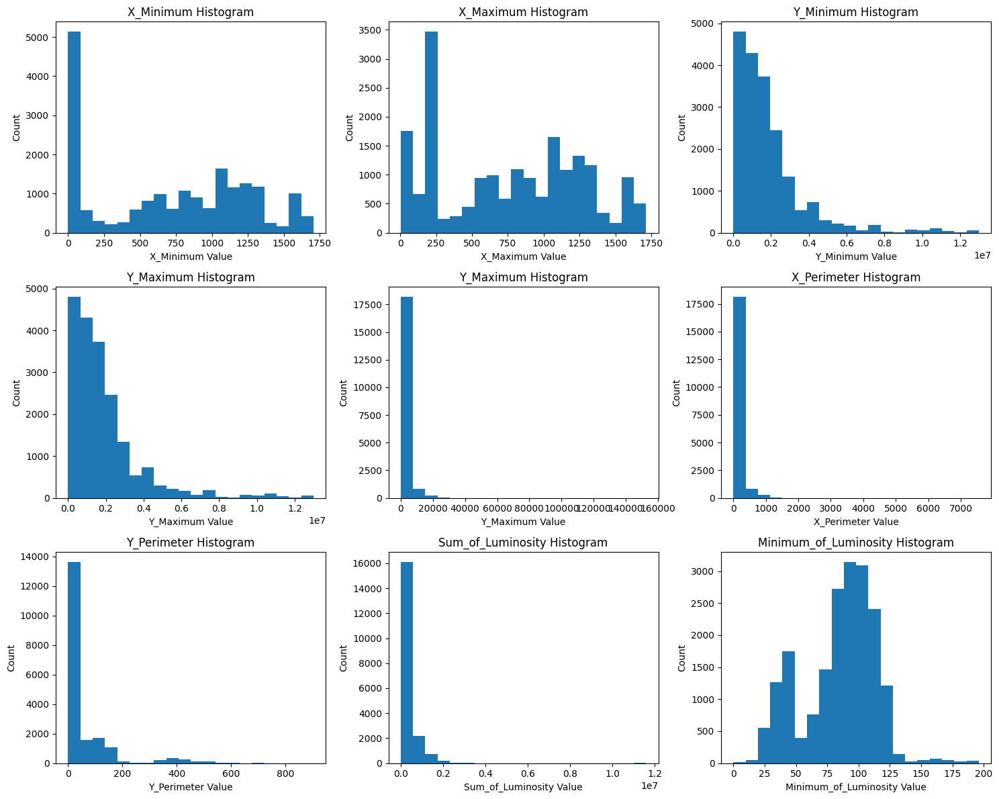

In [ ]:
%matplotlib inline
plt.figure(figsize=(15,12))
plt.subplot(331)
plt.hist(x=data['X_Minimum'], bins=20)
plt.title('X_Minimum Histogram')
plt.xlabel('X_Minimum Value')
plt.ylabel('Count')

plt.subplot(332)
plt.hist(x=data['X_Maximum'], bins=20)
plt.title('X_Maximum Histogram')
plt.xlabel('X_Maximum Value')
plt.ylabel('Count')

plt.subplot(333)
plt.hist(x=data['Y_Minimum'], bins=20)
plt.title('Y_Minimum Histogram')
plt.xlabel('Y_Minimum Value')
plt.ylabel('Count')

plt.subplot(334)
plt.hist(x=data['Y_Maximum'], bins=20)
plt.title('Y_Maximum Histogram')
plt.xlabel('Y_Maximum Value')
plt.ylabel('Count')

plt.subplot(335)
plt.hist(x=data['Pixels_Areas'], bins=20)
plt.title('Y_Maximum Histogram')
plt.xlabel('Y_Maximum Value')
plt.ylabel('Count')

plt.subplot(336)
plt.hist(x=data['X_Perimeter'], bins=20)
plt.title('X_Perimeter Histogram')
plt.xlabel('X_Perimeter Value')
plt.ylabel('Count')

plt.subplot(337)
plt.hist(x=data['Y_Perimeter'], bins=20)
plt.title('Y_Perimeter Histogram')
plt.xlabel('Y_Perimeter Value')
plt.ylabel('Count')

plt.subplot(338)
plt.hist(x=data['Sum_of_Luminosity'], bins=20)
plt.title('Sum_of_Luminosity Histogram')
plt.xlabel('Sum_of_Luminosity Value')
plt.ylabel('Count')

plt.subplot(339)
plt.hist(x=data['Minimum_of_Luminosity'], bins=20)
plt.title('Minimum_of_Luminosity Histogram')
plt.xlabel('Minimum_of_Luminosity Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

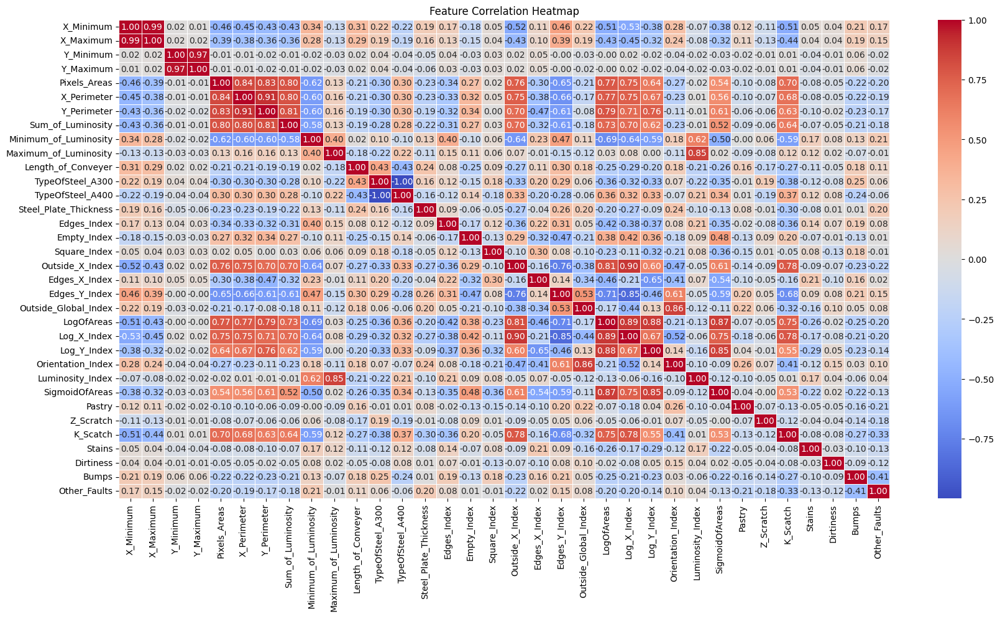

In [ ]:
corr_matrix = data.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("All Features Correlation Heatmap")
plt.show()

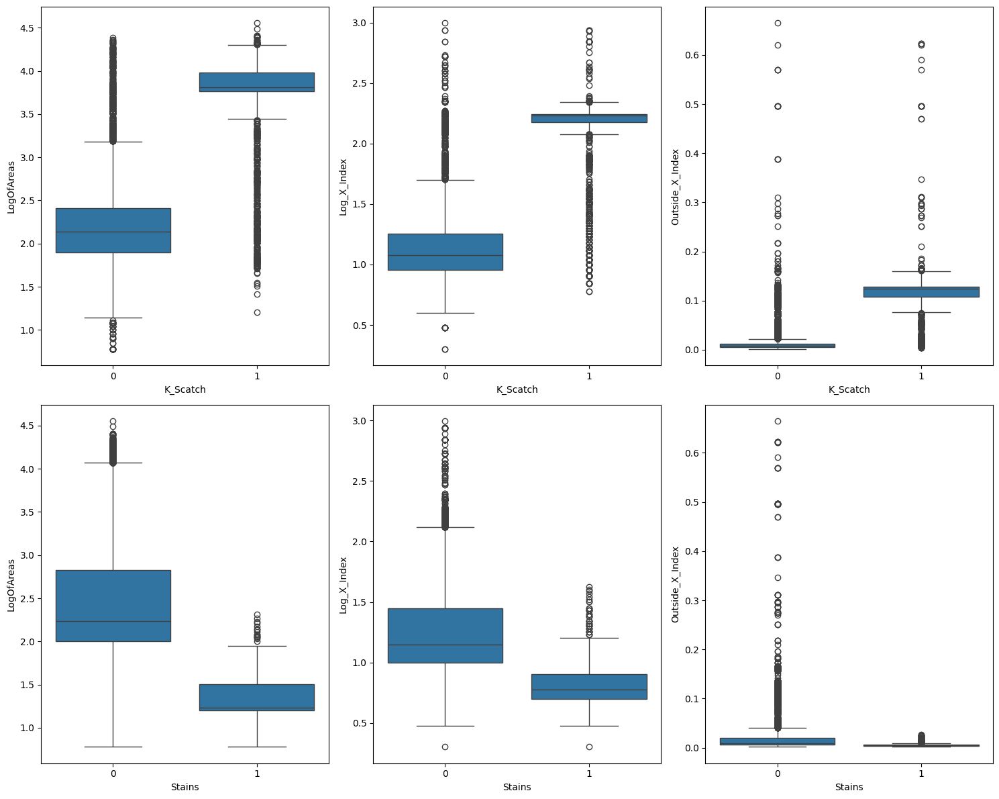

In [ ]:
plt.figure(figsize=(15,12))
plt.subplot(231)
sns.boxplot(x=data['K_Scatch'], y=data['LogOfAreas'])

plt.subplot(232)
sns.boxplot(x=data['K_Scatch'], y=data['Log_X_Index'])

plt.subplot(233)
sns.boxplot(x=data['K_Scatch'], y=data['Outside_X_Index'])

plt.subplot(234)
sns.boxplot(x=data['Stains'], y=data['LogOfAreas'])

plt.subplot(235)
sns.boxplot(x=data['Stains'], y=data['Log_X_Index'])

plt.subplot(236)
sns.boxplot(x=data['Stains'], y=data['Outside_X_Index'])
plt.tight_layout()
plt.show()

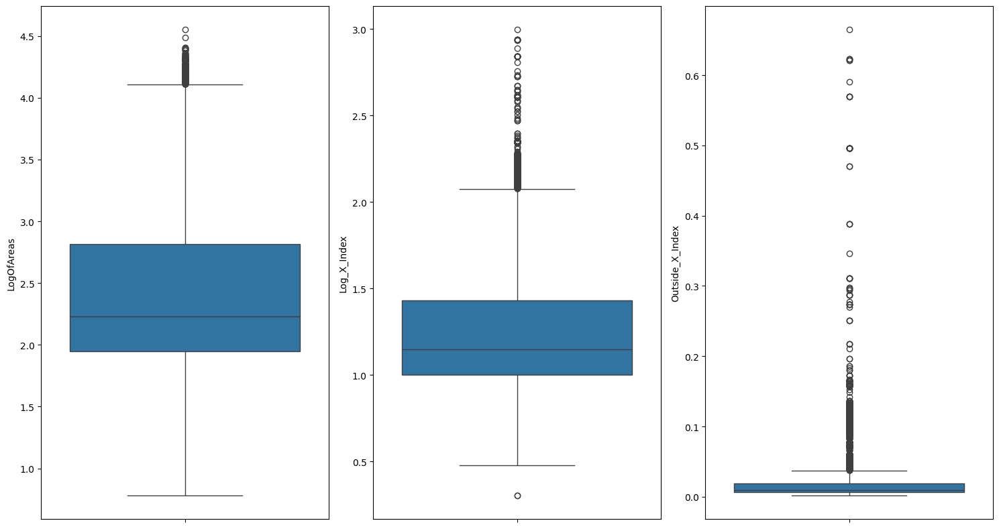

In [ ]:
plt.figure(figsize=(15,8))
plt.subplot(131)
sns.boxplot(y=data['LogOfAreas'])

plt.subplot(132)
sns.boxplot(y=data['Log_X_Index'])

plt.subplot(133)
sns.boxplot(y=data['Outside_X_Index'])

plt.tight_layout()
plt.show()

REMARKS: If we take a look at the histogram above we can see that most of the features are multimodes and some of them are taile heavy (skewed to left). This might indicating some occurences of outliers and since we have multiclass classification case here, it might also indicating that we have mixed up data (data for target feature A, B, C and so on are mixed up inside one features).

Since we don't have any NaN's value, we can go proceed to clean some outliers. Let's try some methods such as:
1. Clean the outliers by deleting them
2. Capped the outliers

In [ ]:
# data_grouped_cleaned = data.copy()
# for col in ['LogOfAreas', 'Log_X_Index', 'Outside_X_Index']:
#     data_grouped_cleaned = outlier_fx_grouped(data_grouped_cleaned, col, 'Stains')

In [ ]:
# def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
#     df_capped = df.copy()

#     for group, group_df in df.groupby(group_col):
#         q1 = group_df[parameter].quantile(0.25)
#         q3 = group_df[parameter].quantile(0.75)
#         iqr = q3 - q1
#         lower = q1 - iqr_multiplier * iqr
#         upper = q3 + iqr_multiplier * iqr

#         mask = df[group_col] == group
#         df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

#     return df_capped

# columns_to_cap = [col for col in data.columns]
# data_grouped_cleaned = data.copy()

# for col in columns_to_cap:
#     data_grouped_cleaned = cap_outliers_by_group(data_grouped_cleaned, col, group_col='Stains')

In [ ]:
# features_main = [col for col in data.columns]
# # features_a = ['Orientation_Index', 'Outside_Global_Index', 'Edges_Y_Index']
# iso = IsolationForest(contamination=0.01, random_state=42)
# data['outlier_flag_main'] = iso.fit_predict(data[features_main])

In [ ]:
# data = data.loc[(data['outlier_flag_main'] == 1), :]
# data

REMARKS: After we did capping and outliers cleaning, we observed that they will increase correlations on one feature target, but will decrease the correlations on other target. Therefore, we will treat this case in One vs Rest classifier. So, first we will split the main data to training data and test data. And from the train data we will seperate the targets and make it binary classifier for each cases. All the trained models would then be stored inside bins/dictionaries along with the dropped features. The stored models would then be used to predict the test data.

In [ ]:
datrain, datest = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
model_library = {}
var_drop = {}

---
## TARGET FEATURE: DATA PASTRY

We start with Target Feature Data Pastry. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_pastry = datrain.copy()
data_pastry.drop(columns=['Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'], inplace=True)
data_pastry

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,1
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,0
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,0
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


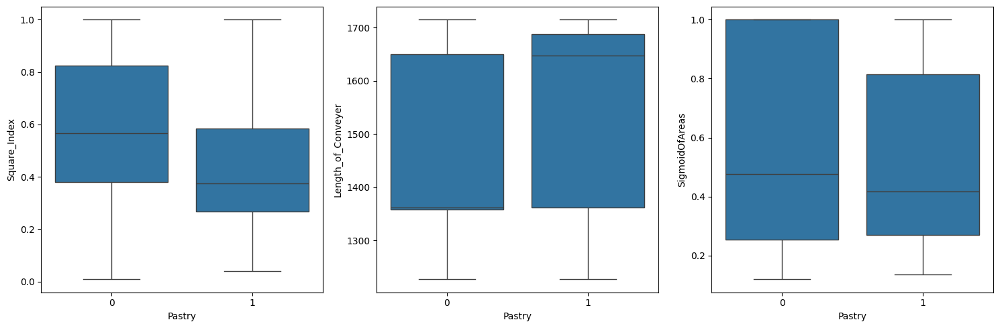

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(131)
sns.boxplot(x=data_pastry['Pastry'], y=data_pastry['Square_Index'])

plt.subplot(132)
sns.boxplot(x=data_pastry['Pastry'], y=data_pastry['Length_of_Conveyer'])

plt.subplot(133)
sns.boxplot(x=data_pastry['Pastry'], y=data_pastry['SigmoidOfAreas'])

plt.tight_layout()
plt.show()

In [ ]:
# X = data_pastry.drop(columns='Pastry')
# y = data_pastry['Pastry']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# rf = RandomForestClassifier(n_estimators=100, max_depth=25, verbose=2, random_state=42)
# rf.fit(X_train, y_train)

# importances = rf.feature_importances_
# feature_names = X.columns

# importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# print(importance_df)
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))  # Top 20
# plt.title('Top Feature Importances from Random Forest')
# plt.tight_layout()
# plt.show()

In [ ]:
# result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
# perm_df = pd.DataFrame({
#     'Feature': X.columns,
#     'Importance Mean': result.importances_mean,
#     'Importance Std': result.importances_std
# }).sort_values(by='Importance Mean', ascending=False)

# print(perm_df)
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance Mean', y='Feature', data=perm_df.head(20), palette='viridis')
# plt.title('Permutation Feature Importance (Top 20)')
# plt.tight_layout()
# plt.show()

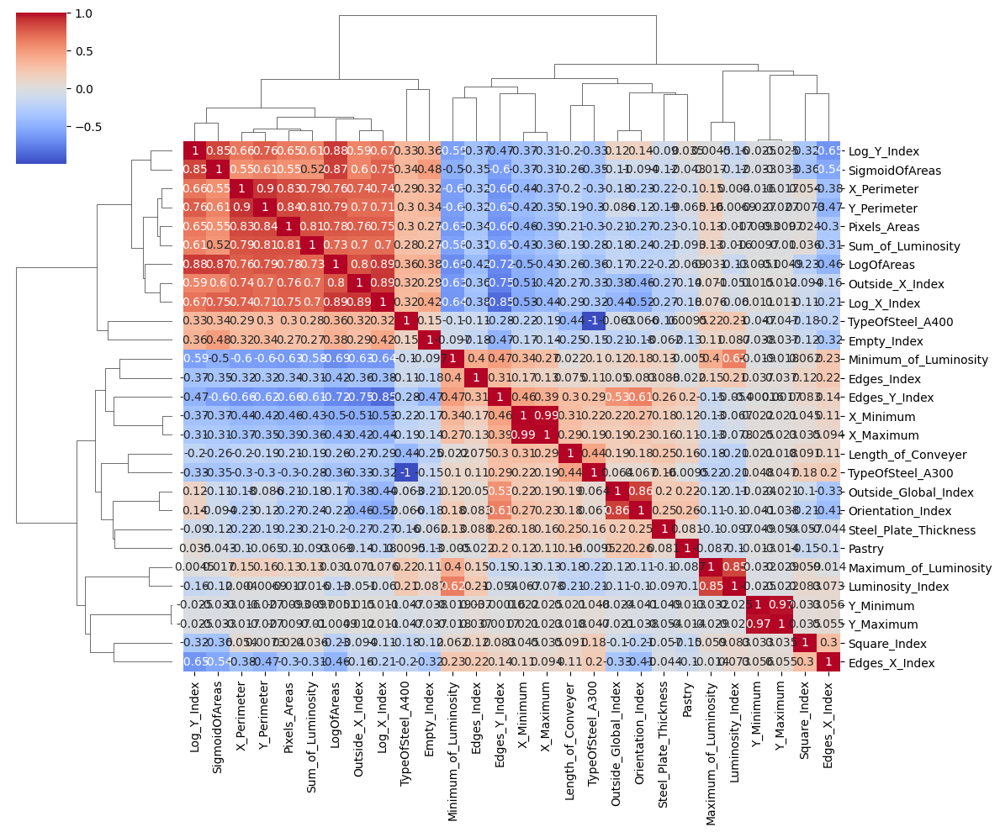

In [ ]:
correlation = data_pastry.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
# features_to_drop = [
#     'X_Maximum',          # Highly correlated with X_Minimum
#     'Y_Maximum',          # Highly correlated with Y_Minimum
#     'X_Perimeter',        # Redundant with Pixels_Areas
#     'Sum_of_Luminosity',  # Redundant with Pixels_Areas
#     'Maximum_of_Luminosity',  # Redundant with Luminosity_Index
#     'SigmoidOfAreas',     # Correlated with Log_Y_Index
#     'Log_X_Index',        # Keep Log_Y_Index instead
#     'Edges_X_Index',      # Redundant with Outside_X_Index
#     'Y_Perimeter',        # Possibly redundant, verify during modeling
# ]

features_to_drop = [
    'X_Maximum',
    'X_Perimeter',
    'Sum_of_Luminosity',
    'Maximum_of_Luminosity',
    'SigmoidOfAreas',
    'Log_X_Index',
    'Edges_X_Index',
    'Y_Perimeter'
]

data_pastry = data_pastry.drop(columns=features_to_drop)

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_pastry.columns if col != 'Pastry']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_pastry = cap_outliers_by_group(data_pastry, col, group_col='Pastry')

/tmp/ipython-input-27-657205493.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 600561.  409986.  439180. ... 1136912. 1569522.  394965.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-27-657205493.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 506794. 1458136. 1144070. ... 1945637.  301511. 1626636.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-27-657205493.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 140.    1603.375  194.    ... 1603.375   1

In [ ]:
# for col in [col for col in data_pastry.columns if col != 'Pastry']:
#     data_pastry = outlier_fx_grouped(data_pastry, col, 'Pastry')

In [ ]:
# plt.figure(figsize=(25,15))
# sns.clustermap(data_pastry.corr(numeric_only=True), cmap='coolwarm', annot=True, figsize=(12, 10))
# plt.show()

In [ ]:
data.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')

In [ ]:
features_a = [col for col in data_pastry.columns if col != 'Pastry']
# features_a = ['Orientation_Index', 'Outside_Global_Index', 'Edges_Y_Index']
iso = IsolationForest(contamination=0.01, random_state=42)
data_pastry['outlier_flag_a'] = iso.fit_predict(data_pastry[features_a])

In [ ]:
data_pastry = data_pastry.loc[(data_pastry['outlier_flag_a'] == 1), :]
data_pastry

,X_Minimum,Y_Minimum,Y_Maximum,Pixels_Areas,Minimum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,...,Square_Index,Outside_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_Y_Index,Orientation_Index,Luminosity_Index,Pastry,outlier_flag_a
9002,921,506783.0,506794.0,140.000,84,1360,1,0,140,0.6195,...,0.8571,0.01030,1.0000,0.0,2.14610,1.1139,-0.1429,-0.24920,0,1
4731,779,1458128.0,1458136.0,1603.375,88,1358,0,1,40,0.7067,...,0.3452,0.04335,0.6286,0.0,3.34040,1.6721,-0.6548,-0.18210,0,1
4125,1323,600561.0,600841.0,627.500,99,1353,0,1,70,0.0739,...,0.2432,0.00810,1.0000,1.0,3.21045,2.1595,0.7568,-0.14350,1,1
1372,1277,1144047.0,1144070.0,194.000,84,1694,1,0,60,0.1213,...,0.9412,0.01260,0.9444,0.0,2.28780,1.2305,-0.0588,-0.23970,0,1
984,39,1814642.0,1814708.0,1603.375,49,1356,0,1,40,0.0575,...,0.3454,0.04335,0.5664,0.0,3.63660,1.7708,-0.6546,-0.13820,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1803992.0,1804016.0,1603.375,36,1400,0,1,40,0.0586,...,0.9448,0.04335,0.3689,0.0,4.19640,2.0086,-0.0553,-0.35625,0,1
11964,1677,1720569.0,1720592.0,196.000,55,1692,1,0,80,0.0071,...,0.2581,0.00590,1.0000,1.0,2.29230,1.4914,0.7419,-0.35625,0,1
5390,39,1945494.0,1945637.0,1603.375,119,1356,0,1,40,0.0557,...,0.4000,0.04335,0.4465,0.0,4.09740,2.1732,-0.6000,-0.09700,0,1
860,604,301492.0,301511.0,16.000,120,1358,0,1,50,0.6667,...,0.6667,0.00590,1.0000,0.0,1.20410,0.6021,-0.3333,0.00190,0,1


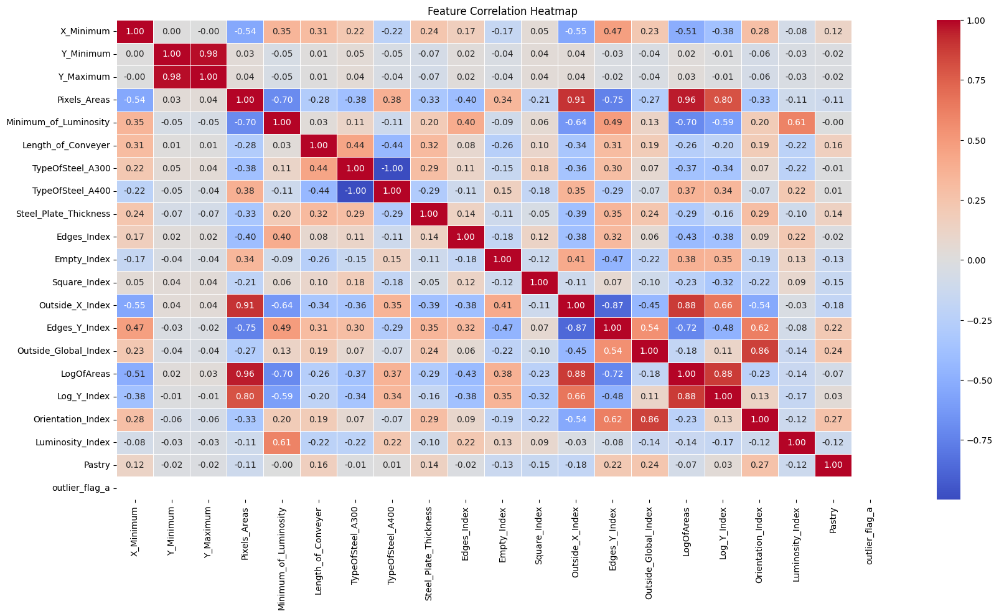

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_pastry.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
features = [col for col in data_pastry.columns if (col != 'Pastry') & (col != 'Y_Maximum')]
y = data_pastry['Pastry']

def correlation_vote_filter(X, y, threshold=0.05):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_pastry[features], y, threshold=0.05)
corr_feat

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipython-input-34-3418321579.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(X[col], y)
/tmp/ipython-input-34-3418321579.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(X[col], y)


['Y_Minimum',
 'Minimum_of_Luminosity',
 'TypeOfSteel_A300',
 'TypeOfSteel_A400',
 'Edges_Index',
 'outlier_flag_a']

In [ ]:
data_pastry.drop(columns=corr_feat, inplace=True)
data_pastry

,X_Minimum,Y_Maximum,Pixels_Areas,Length_of_Conveyer,Steel_Plate_Thickness,Empty_Index,Square_Index,Outside_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_Y_Index,Orientation_Index,Luminosity_Index,Pastry
9002,921,506794.0,140.000,1360,140,0.3175,0.8571,0.01030,1.0000,0.0,2.14610,1.1139,-0.1429,-0.24920,0
4731,779,1458136.0,1603.375,1358,40,0.3864,0.3452,0.04335,0.6286,0.0,3.34040,1.6721,-0.6548,-0.18210,0
4125,1323,600841.0,627.500,1353,70,0.4676,0.2432,0.00810,1.0000,1.0,3.21045,2.1595,0.7568,-0.14350,1
1372,1277,1144070.0,194.000,1694,60,0.2734,0.9412,0.01260,0.9444,0.0,2.28780,1.2305,-0.0588,-0.23970,0
984,39,1814708.0,1603.375,1356,40,0.3916,0.3454,0.04335,0.5664,0.0,3.63660,1.7708,-0.6546,-0.13820,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,1603.375,1400,40,0.5180,0.9448,0.04335,0.3689,0.0,4.19640,2.0086,-0.0553,-0.35625,0
11964,1677,1720592.0,196.000,1692,80,0.3647,0.2581,0.00590,1.0000,1.0,2.29230,1.4914,0.7419,-0.35625,0
5390,39,1945637.0,1603.375,1356,40,0.4768,0.4000,0.04335,0.4465,0.0,4.09740,2.1732,-0.6000,-0.09700,0
860,604,301511.0,16.000,1358,50,0.3400,0.6667,0.00590,1.0000,0.0,1.20410,0.6021,-0.3333,0.00190,0


In [ ]:
X_all = data_pastry.drop(columns='Pastry')
y_all = data_pastry['Pastry']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

clf_all_pastry = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_pastry.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_pastry.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

building tree 1 of 120
building tree 2 of 120
building tree 3 of 120
building tree 4 of 120
building tree 5 of 120
building tree 6 of 120
building tree 7 of 120
building tree 8 of 120
building tree 9 of 120
building tree 10 of 120
building tree 11 of 120
building tree 12 of 120
building tree 13 of 120
building tree 14 of 120
building tree 15 of 120
building tree 16 of 120
building tree 17 of 120
building tree 18 of 120
building tree 19 of 120
building tree 20 of 120
building tree 21 of 120
building tree 22 of 120
building tree 23 of 120
building tree 24 of 120
building tree 25 of 120
building tree 26 of 120
building tree 27 of 120
building tree 28 of 120
building tree 29 of 120
building tree 30 of 120
building tree 31 of 120
building tree 32 of 120
building tree 33 of 120
building tree 34 of 120
building tree 35 of 120
building tree 36 of 120
building tree 37 of 120
building tree 38 of 120
building tree 39 of 120
building tree 40 of 120
building tree 41 of 120
building tree 42 of 120
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.7s


building tree 48 of 120
building tree 49 of 120
building tree 50 of 120
building tree 51 of 120
building tree 52 of 120
building tree 53 of 120
building tree 54 of 120
building tree 55 of 120
building tree 56 of 120
building tree 57 of 120
building tree 58 of 120
building tree 59 of 120
building tree 60 of 120
building tree 61 of 120
building tree 62 of 120
building tree 63 of 120
building tree 64 of 120
building tree 65 of 120
building tree 66 of 120
building tree 67 of 120
building tree 68 of 120
building tree 69 of 120
building tree 70 of 120
building tree 71 of 120
building tree 72 of 120
building tree 73 of 120
building tree 74 of 120
building tree 75 of 120
building tree 76 of 120
building tree 77 of 120
building tree 78 of 120
building tree 79 of 120
building tree 80 of 120
building tree 81 of 120
building tree 82 of 120
building tree 83 of 120
building tree 84 of 120
building tree 85 of 120
building tree 86 of 120
building tree 87 of 120
building tree 88 of 120
building tree 89

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished


In [ ]:
# lgbm_all = LGBMClassifier(n_estimators=120, max_depth=25, verbosity=2, learning_rate=0.1, random_state=42)
# lgbm_all.fit(X_train_all, y_train_all)

# y_pred_proba_lgbm = lgbm_all.predict_proba(X_val_all)[:, 1]
# roc_lgbm = roc_auc_score(y_val_all, y_pred_proba_lgbm)
# print(f"ROC AUC (All Data): {roc_lgbm:.2f}")

In [ ]:
model_library[0] = clf_all_pastry
drop_sublist = ['X_Maximum','X_Perimeter', 'Sum_of_Luminosity',
             'Maximum_of_Luminosity', 'SigmoidOfAreas', 'Log_X_Index',
             'Edges_X_Index', 'Y_Perimeter', 'Y_Minimum', 'Minimum_of_Luminosity', 'TypeOfSteel_A300',
             'TypeOfSteel_A400', 'Edges_Index']
var_drop[0] = drop_sublist

---
## TARGET FEATURE: Z-SCRATCH DATA

We continue with Target Feature Data Z-Scratch. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_zscratch = datrain.copy()
data_zscratch.drop(columns=['Pastry', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'], inplace=True)
data_zscratch

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Z_Scratch
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,0
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,0
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


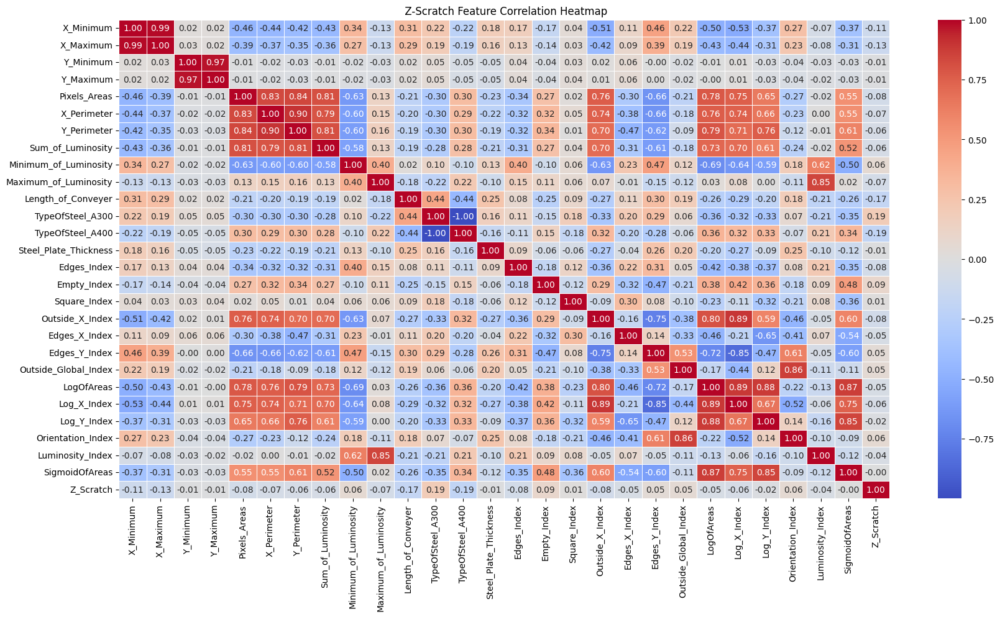

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_zscratch.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(" Z-Scratch Feature Correlation Heatmap")
plt.show()

In [ ]:
data.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')

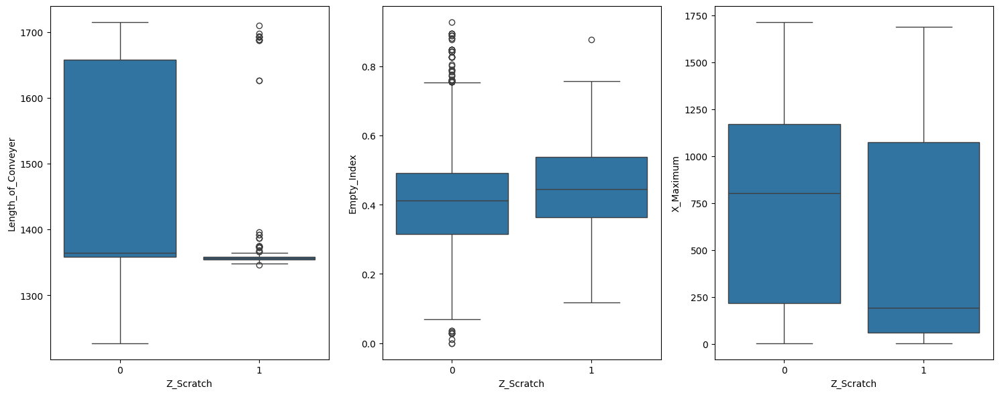

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(131)
sns.boxplot(x=data_zscratch['Z_Scratch'], y=data_zscratch['Length_of_Conveyer'])
plt.subplot(132)
sns.boxplot(x=data_zscratch['Z_Scratch'], y=data_zscratch['Empty_Index'])
plt.subplot(133)
sns.boxplot(x=data_zscratch['Z_Scratch'], y=data_zscratch['X_Maximum'])

plt.tight_layout()
plt.show()

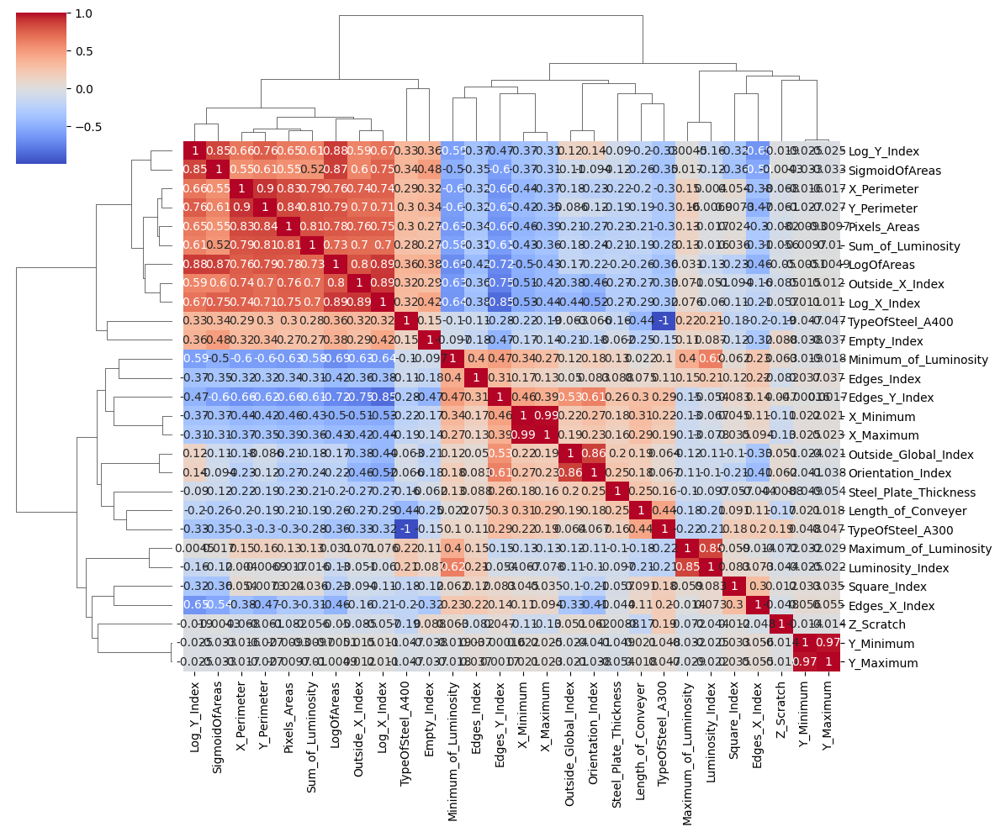

In [ ]:
correlation = data_zscratch.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
features_to_drop = [
    'Y_Minimum',
    'Y_Perimeter',
    'X_Minimum',
    'Log_X_Index',
    'Outside_Global_Index',
    'Luminosity_Index',
    'Log_Y_Index',
    'SigmoidOfAreas'
]

data_zscratch = data_zscratch.drop(columns=features_to_drop)
data_zscratch

,X_Maximum,Y_Maximum,Pixels_Areas,X_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,LogOfAreas,Orientation_Index,Z_Scratch
9002,934,506794,140,22,14742,84,111,1360,1,0,300,0.6195,0.3175,0.8571,0.0103,0.6842,1.0000,2.1461,-0.1429,0
4731,842,1458136,2160,173,275539,88,124,1358,0,1,40,0.7067,0.3864,0.3452,0.0776,0.7813,0.6286,3.3404,-0.6548,0
4125,1333,600841,2243,165,262543,99,125,1353,0,1,70,0.0739,0.4676,0.2432,0.0081,0.2000,0.9789,3.3508,0.7568,0
1372,1290,1144070,194,21,19202,84,118,1694,1,0,60,0.1213,0.2734,0.9412,0.0126,0.8095,0.9444,2.2878,-0.0588,0
984,212,1814708,4788,256,516343,49,127,1356,0,1,40,0.0575,0.3916,0.3454,0.1261,0.6914,0.5664,3.6366,-0.6546,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,218,1804016,16686,805,2013557,36,141,1400,0,1,40,0.0586,0.5180,0.9448,0.1264,0.2119,0.3689,4.2296,-0.0553,0
11964,1688,1720592,196,23,12221,55,94,1692,1,0,80,0.0071,0.3647,0.2581,0.0059,0.4348,1.0000,2.2923,0.7419,0
5390,185,1945637,12012,319,1381722,119,141,1356,0,1,40,0.0557,0.4768,0.4000,0.1043,0.7222,0.4465,4.0974,-0.6000,0
860,611,301511,16,10,2034,120,140,1358,0,1,50,0.6667,0.3400,0.6667,0.0059,0.8000,1.0000,1.2041,-0.3333,0


In [ ]:
# for col in [col for col in data_zscratch.columns if col != 'Z_Scratch']:
#      data_zscratch = outlier_fx_grouped(data_zscratch, col, 'Z_Scratch')

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_zscratch.columns if col != 'Z_Scratch']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_zscratch = cap_outliers_by_group(data_zscratch, col, group_col='Z_Scratch')

/tmp/ipython-input-46-2810416700.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 506794. 1458136.  600841. ... 1945637.  301511. 1626636.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-46-2810416700.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[150.   131.   110.    83.    85.   117.   476.    69.   289.   704.25
 521.   155.   704.25  83.   543.   116.    62.    64.   265.   139.
 339.   677.   460.   313.   704.25  74.   168.   313.   566.   209.
 111.   122.   110.   677.    83.    83.    52.    60.   169.   117.
  98.   704.25 217.   657.   166.    69.   339.   209.   704.25 231.
 104.   109.    66.    63.   704.25  68.   120.   539.   217.   146.
 677.   313.   704.2

In [ ]:
features_b = [col for col in data_zscratch.columns if col != 'Z_Scratch']
iso = IsolationForest(contamination=0.01, random_state=42)
data_zscratch['outlier_flag_b'] = iso.fit_predict(data_zscratch[features_b])

In [ ]:
data_zcratch = data_zscratch.loc[(data_zscratch['outlier_flag_b'] == 1), :]
data_zscratch

,X_Maximum,Y_Maximum,Pixels_Areas,X_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,LogOfAreas,Orientation_Index,Z_Scratch,outlier_flag_b
9002,934,506794.0,140.0,22,14742.0,84.0,111.0,1360,1,0,...,0.6195,0.3175,0.8571,0.0103,0.6842,1.0000,2.1461,-0.1429,0,1
4731,842,1458136.0,1544.0,145,163570.5,88.0,124.0,1358,0,1,...,0.7067,0.3864,0.3452,0.0396,0.7813,0.6286,3.3404,-0.6548,0,1
4125,1333,600841.0,1544.0,145,163570.5,99.0,125.0,1353,0,1,...,0.0739,0.4676,0.2432,0.0081,0.2000,0.9789,3.3508,0.7568,0,1
1372,1290,1144070.0,194.0,21,19202.0,84.0,118.0,1694,1,0,...,0.1213,0.2734,0.9412,0.0126,0.8095,0.9444,2.2878,-0.0588,0,1
984,212,1814708.0,1544.0,145,163570.5,49.0,127.0,1356,0,1,...,0.0575,0.3916,0.3454,0.0396,0.6914,0.5664,3.6366,-0.6546,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,218,1804016.0,1544.0,145,163570.5,36.0,141.0,1400,0,1,...,0.0586,0.5180,0.9448,0.0396,0.2119,0.3689,4.1524,-0.0553,0,1
11964,1688,1720592.0,196.0,23,12221.0,55.0,107.5,1692,1,0,...,0.0071,0.3647,0.2581,0.0059,0.4348,1.0000,2.2923,0.7419,0,1
5390,185,1945637.0,1544.0,145,163570.5,119.0,141.0,1356,0,1,...,0.0557,0.4768,0.4000,0.0396,0.7222,0.4465,4.0974,-0.6000,0,1
860,611,301511.0,16.0,10,2034.0,120.0,140.0,1358,0,1,...,0.6667,0.3400,0.6667,0.0059,0.8000,1.0000,1.2041,-0.3333,0,1


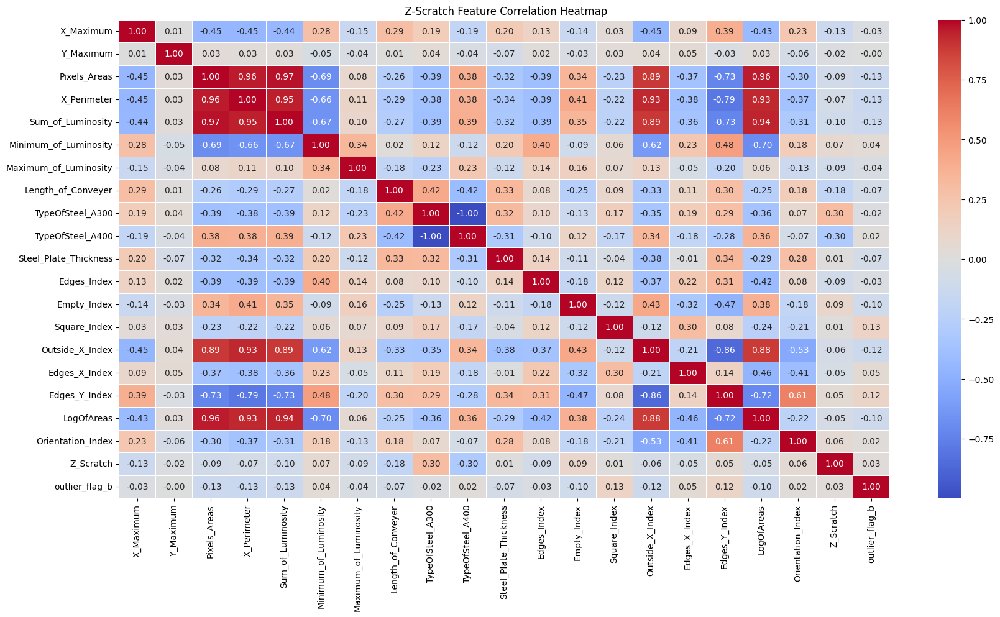

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_zscratch.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(" Z-Scratch Feature Correlation Heatmap")
plt.show()

In [ ]:
features = [col for col in data_zscratch.columns if (col != 'Z_Scratch')]
y = data_zscratch['Z_Scratch']

def correlation_vote_filter(X, y, threshold=0.05):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_zscratch[features], y, threshold=0.05)
corr_feat

['Y_Maximum', 'Square_Index', 'outlier_flag_b']

In [ ]:
data_zscratch.drop(columns=corr_feat, inplace=True)
data_zscratch

,X_Maximum,Pixels_Areas,X_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,LogOfAreas,Orientation_Index,Z_Scratch
9002,934,140.0,22,14742.0,84.0,111.0,1360,1,0,140,0.6195,0.3175,0.0103,0.6842,1.0000,2.1461,-0.1429,0
4731,842,1544.0,145,163570.5,88.0,124.0,1358,0,1,40,0.7067,0.3864,0.0396,0.7813,0.6286,3.3404,-0.6548,0
4125,1333,1544.0,145,163570.5,99.0,125.0,1353,0,1,70,0.0739,0.4676,0.0081,0.2000,0.9789,3.3508,0.7568,0
1372,1290,194.0,21,19202.0,84.0,118.0,1694,1,0,60,0.1213,0.2734,0.0126,0.8095,0.9444,2.2878,-0.0588,0
984,212,1544.0,145,163570.5,49.0,127.0,1356,0,1,40,0.0575,0.3916,0.0396,0.6914,0.5664,3.6366,-0.6546,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,218,1544.0,145,163570.5,36.0,141.0,1400,0,1,40,0.0586,0.5180,0.0396,0.2119,0.3689,4.1524,-0.0553,0
11964,1688,196.0,23,12221.0,55.0,107.5,1692,1,0,80,0.0071,0.3647,0.0059,0.4348,1.0000,2.2923,0.7419,0
5390,185,1544.0,145,163570.5,119.0,141.0,1356,0,1,40,0.0557,0.4768,0.0396,0.7222,0.4465,4.0974,-0.6000,0
860,611,16.0,10,2034.0,120.0,140.0,1358,0,1,50,0.6667,0.3400,0.0059,0.8000,1.0000,1.2041,-0.3333,0


In [ ]:
X_all = data_zscratch.drop(columns='Z_Scratch')
y_all = data_zscratch['Z_Scratch']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

clf_all_zscratch = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_zscratch.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_zscratch.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

building tree 1 of 120
building tree 2 of 120
building tree 3 of 120
building tree 4 of 120
building tree 5 of 120
building tree 6 of 120
building tree 7 of 120
building tree 8 of 120
building tree 9 of 120
building tree 10 of 120
building tree 11 of 120
building tree 12 of 120
building tree 13 of 120
building tree 14 of 120
building tree 15 of 120
building tree 16 of 120
building tree 17 of 120
building tree 18 of 120
building tree 19 of 120
building tree 20 of 120
building tree 21 of 120
building tree 22 of 120
building tree 23 of 120
building tree 24 of 120
building tree 25 of 120
building tree 26 of 120
building tree 27 of 120
building tree 28 of 120
building tree 29 of 120
building tree 30 of 120
building tree 31 of 120
building tree 32 of 120
building tree 33 of 120
building tree 34 of 120
building tree 35 of 120
building tree 36 of 120
building tree 37 of 120
building tree 38 of 120
building tree 39 of 120
building tree 40 of 120
building tree 41 of 120
building tree 42 of 120
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s


building tree 49 of 120
building tree 50 of 120
building tree 51 of 120
building tree 52 of 120
building tree 53 of 120
building tree 54 of 120
building tree 55 of 120
building tree 56 of 120
building tree 57 of 120
building tree 58 of 120
building tree 59 of 120
building tree 60 of 120
building tree 61 of 120
building tree 62 of 120
building tree 63 of 120
building tree 64 of 120
building tree 65 of 120
building tree 66 of 120
building tree 67 of 120
building tree 68 of 120
building tree 69 of 120
building tree 70 of 120
building tree 71 of 120
building tree 72 of 120
building tree 73 of 120
building tree 74 of 120
building tree 75 of 120
building tree 76 of 120
building tree 77 of 120
building tree 78 of 120
building tree 79 of 120
building tree 80 of 120
building tree 81 of 120
building tree 82 of 120
building tree 83 of 120
building tree 84 of 120
building tree 85 of 120
building tree 86 of 120
building tree 87 of 120
building tree 88 of 120
building tree 89 of 120
building tree 90

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished


In [ ]:
model_library[1] = clf_all_zscratch
drop_sublist = ['Y_Minimum', 'Y_Perimeter', 'X_Minimum', 'Log_X_Index', 'Outside_Global_Index','Luminosity_Index',
                'Log_Y_Index', 'SigmoidOfAreas', 'Y_Maximum', 'Square_Index']
var_drop[1] = drop_sublist

## TARGET FEATURE: K-SCATCH DATA

We continue with Target Feature Data K-Scatch. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_k = datrain.copy()
data_k.drop(columns=['Pastry', 'Z_Scratch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'], inplace=True)
data_k

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,K_Scatch
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,0
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,1
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


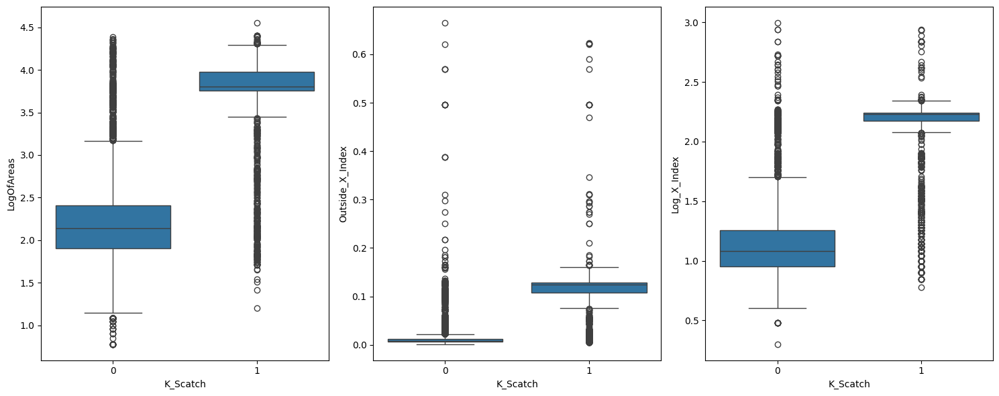

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(131)
sns.boxplot(x=data_k['K_Scatch'], y=data_k['LogOfAreas'])
plt.subplot(132)
sns.boxplot(x=data_k['K_Scatch'], y=data_k['Outside_X_Index'])
plt.subplot(133)
sns.boxplot(x=data_k['K_Scatch'], y=data_k['Log_X_Index'])

plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_k.columns if col != 'K_scatch']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_k = cap_outliers_by_group(data_k, col, group_col='K_Scatch')

/tmp/ipython-input-56-1523609785.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1814642. 1157189. 1821207. ... 2098521. 1945494. 1626575.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-56-1523609785.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1814708. 1157378. 1821379. ... 2098591. 1945637. 1626636.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-56-1523609785.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[22.  66.5 66.5 ... 66.5 23.  10. ]' has 

In [ ]:
# for col in [col for col in data_k.columns if col != 'K_Scatch']:
#       data_k = outlier_fx_grouped(data_k, col, 'K_Scatch')

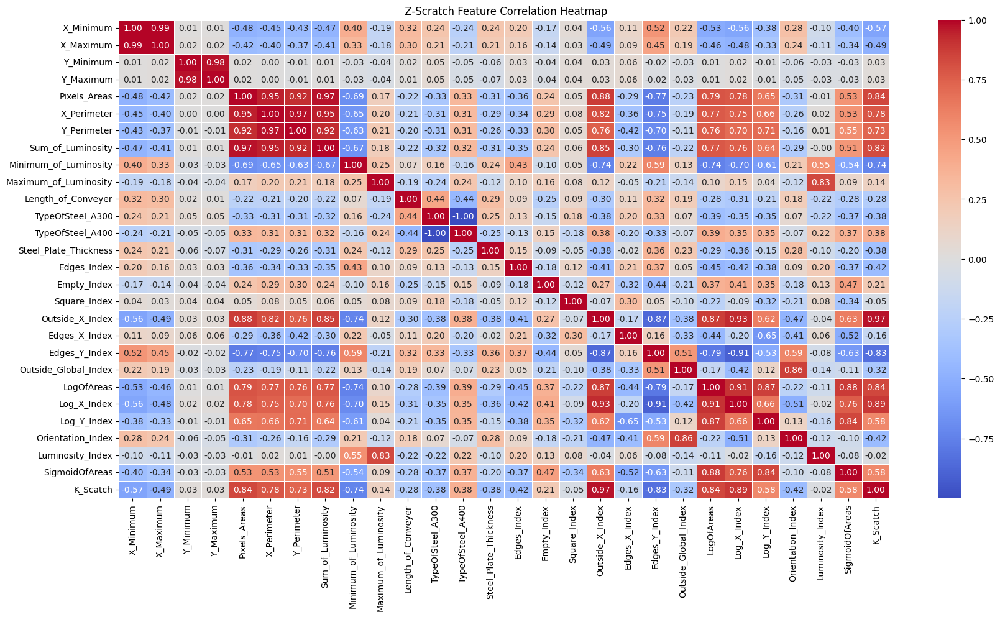

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_k.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(" Z-Scratch Feature Correlation Heatmap")
plt.show()

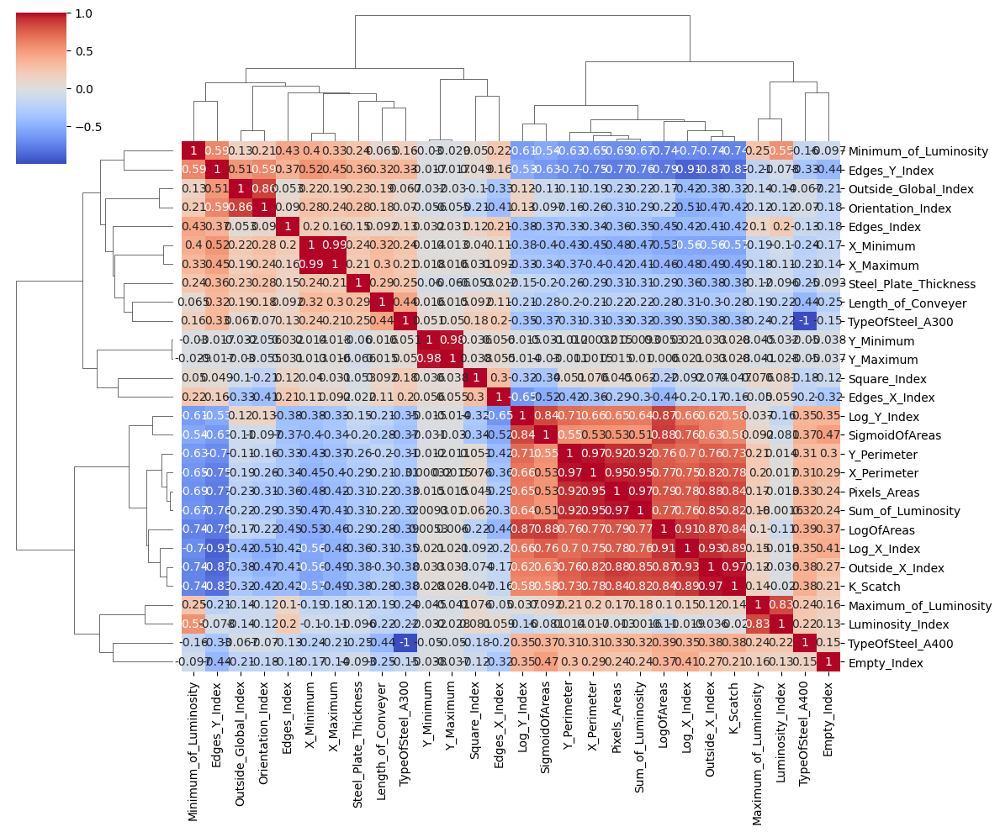

In [ ]:
correlation = data_k.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
features_to_drop = [
    'Outside_X_Index',
    'LogOfAreas',
    'Sum_of_Luminosity',
    'Y_Perimeter',
    'Y_Minimum',
    'X_Maximum',
    'Outside_Global_Index',
    'Pixels_Areas'
]

data_k = data_k.drop(columns=features_to_drop)
data_k

,X_Minimum,Y_Maximum,X_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Edges_X_Index,Edges_Y_Index,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,K_Scatch
9002,921,506794.0,22.0,84.0,111.0,1360,1,0,165,0.6195,0.3175,0.8571,0.6842,1.0000,1.14610,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,1458136.0,66.5,88.0,124.0,1358,0,1,40,0.7067,0.3864,0.3452,0.7813,0.6875,1.70695,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,600841.0,66.5,99.0,125.0,1353,0,1,70,0.0739,0.4676,0.2432,0.2000,0.9789,1.04140,2.0372,0.7568,-0.1435,1.0000,0
1372,1277,1144070.0,21.0,84.0,118.0,1694,1,0,60,0.1213,0.2734,0.9412,0.8095,0.9444,1.23050,1.2305,-0.0588,-0.2397,0.4498,0
984,39,1814708.0,256.0,49.0,127.0,1356,0,1,40,0.0575,0.3916,0.3454,0.6914,0.5664,2.23300,1.7708,-0.6546,-0.1382,1.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,66.5,44.5,141.0,1400,0,1,40,0.0586,0.5180,0.9448,0.2119,0.6875,1.70695,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1720592.0,23.0,55.0,109.0,1692,1,0,80,0.0071,0.3647,0.2581,0.4348,1.0000,1.00000,1.4914,0.7419,-0.3958,0.4106,0
5390,39,1945637.0,319.0,56.0,141.0,1356,0,1,40,0.0557,0.4768,0.4000,0.7222,0.4465,2.16440,2.1732,-0.6000,-0.0970,1.0000,1
860,604,301511.0,10.0,120.0,140.0,1358,0,1,50,0.6667,0.3400,0.6667,0.8000,1.0000,0.90310,0.6021,-0.3333,0.0019,0.1353,0


In [ ]:
features_c = [col for col in data_k.columns if col != 'K_Scatch']
iso = IsolationForest(contamination=0.01, random_state=42)
data_k['outlier_flag_c'] = iso.fit_predict(data_k[features_c])

In [ ]:
data_k = data_k.loc[(data_k['outlier_flag_c'] == 1), :]
data_k

,X_Minimum,Y_Maximum,X_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,...,Square_Index,Edges_X_Index,Edges_Y_Index,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,K_Scatch,outlier_flag_c
9002,921,506794.0,22.0,84.0,111.0,1360,1,0,165,0.6195,...,0.8571,0.6842,1.0000,1.14610,1.1139,-0.1429,-0.2492,0.2901,0,1
4731,779,1458136.0,66.5,88.0,124.0,1358,0,1,40,0.7067,...,0.3452,0.7813,0.6875,1.70695,1.6721,-0.6548,-0.1821,1.0000,0,1
4125,1323,600841.0,66.5,99.0,125.0,1353,0,1,70,0.0739,...,0.2432,0.2000,0.9789,1.04140,2.0372,0.7568,-0.1435,1.0000,0,1
1372,1277,1144070.0,21.0,84.0,118.0,1694,1,0,60,0.1213,...,0.9412,0.8095,0.9444,1.23050,1.2305,-0.0588,-0.2397,0.4498,0,1
984,39,1814708.0,256.0,49.0,127.0,1356,0,1,40,0.0575,...,0.3454,0.6914,0.5664,2.23300,1.7708,-0.6546,-0.1382,1.0000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,66.5,44.5,141.0,1400,0,1,40,0.0586,...,0.9448,0.2119,0.6875,1.70695,2.0086,-0.0553,-0.3805,1.0000,0,1
11964,1677,1720592.0,23.0,55.0,109.0,1692,1,0,80,0.0071,...,0.2581,0.4348,1.0000,1.00000,1.4914,0.7419,-0.3958,0.4106,0,1
5390,39,1945637.0,319.0,56.0,141.0,1356,0,1,40,0.0557,...,0.4000,0.7222,0.4465,2.16440,2.1732,-0.6000,-0.0970,1.0000,1,1
860,604,301511.0,10.0,120.0,140.0,1358,0,1,50,0.6667,...,0.6667,0.8000,1.0000,0.90310,0.6021,-0.3333,0.0019,0.1353,0,1


In [ ]:
features = [col for col in data_k.columns if (col != 'K_Scatch')]
y = data_k['K_Scatch']

def correlation_vote_filter(X, y, threshold=0.05):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_k[features], y, threshold=0.4)
corr_feat

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipython-input-63-1187408418.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(X[col], y)
/tmp/ipython-input-63-1187408418.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(X[col], y)


['Y_Maximum',
 'Maximum_of_Luminosity',
 'Length_of_Conveyer',
 'TypeOfSteel_A300',
 'TypeOfSteel_A400',
 'Empty_Index',
 'Square_Index',
 'Edges_X_Index',
 'Luminosity_Index',
 'outlier_flag_c']

In [ ]:
data_k.drop(columns=corr_feat, inplace=True)
data_k

/tmp/ipython-input-64-4255970467.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_k.drop(columns=corr_feat, inplace=True)


,X_Minimum,X_Perimeter,Minimum_of_Luminosity,Steel_Plate_Thickness,Edges_Index,Edges_Y_Index,Log_X_Index,Log_Y_Index,Orientation_Index,SigmoidOfAreas,K_Scatch
9002,921,22.0,84.0,165,0.6195,1.0000,1.14610,1.1139,-0.1429,0.2901,0
4731,779,66.5,88.0,40,0.7067,0.6875,1.70695,1.6721,-0.6548,1.0000,0
4125,1323,66.5,99.0,70,0.0739,0.9789,1.04140,2.0372,0.7568,1.0000,0
1372,1277,21.0,84.0,60,0.1213,0.9444,1.23050,1.2305,-0.0588,0.4498,0
984,39,256.0,49.0,40,0.0575,0.5664,2.23300,1.7708,-0.6546,1.0000,1
...,...,...,...,...,...,...,...,...,...,...,...
11284,41,66.5,44.5,40,0.0586,0.6875,1.70695,2.0086,-0.0553,1.0000,0
11964,1677,23.0,55.0,80,0.0071,1.0000,1.00000,1.4914,0.7419,0.4106,0
5390,39,319.0,56.0,40,0.0557,0.4465,2.16440,2.1732,-0.6000,1.0000,1
860,604,10.0,120.0,50,0.6667,1.0000,0.90310,0.6021,-0.3333,0.1353,0


In [ ]:
X_all = data_k.drop(columns='K_Scatch')
y_all = data_k['K_Scatch']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

clf_all_kscatch = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_kscatch.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_kscatch.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

building tree 1 of 120
building tree 2 of 120
building tree 3 of 120
building tree 4 of 120
building tree 5 of 120
building tree 6 of 120
building tree 7 of 120
building tree 8 of 120
building tree 9 of 120
building tree 10 of 120
building tree 11 of 120
building tree 12 of 120
building tree 13 of 120
building tree 14 of 120
building tree 15 of 120
building tree 16 of 120
building tree 17 of 120
building tree 18 of 120
building tree 19 of 120
building tree 20 of 120
building tree 21 of 120
building tree 22 of 120
building tree 23 of 120
building tree 24 of 120
building tree 25 of 120
building tree 26 of 120
building tree 27 of 120
building tree 28 of 120
building tree 29 of 120
building tree 30 of 120
building tree 31 of 120
building tree 32 of 120
building tree 33 of 120
building tree 34 of 120
building tree 35 of 120
building tree 36 of 120
building tree 37 of 120
building tree 38 of 120
building tree 39 of 120
building tree 40 of 120
building tree 41 of 120
building tree 42 of 120
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.2s


building tree 45 of 120
building tree 46 of 120
building tree 47 of 120
building tree 48 of 120
building tree 49 of 120
building tree 50 of 120
building tree 51 of 120
building tree 52 of 120
building tree 53 of 120
building tree 54 of 120
building tree 55 of 120
building tree 56 of 120
building tree 57 of 120
building tree 58 of 120
building tree 59 of 120
building tree 60 of 120
building tree 61 of 120
building tree 62 of 120
building tree 63 of 120
building tree 64 of 120
building tree 65 of 120
building tree 66 of 120
building tree 67 of 120
building tree 68 of 120
building tree 69 of 120
building tree 70 of 120
building tree 71 of 120
building tree 72 of 120
building tree 73 of 120
building tree 74 of 120
building tree 75 of 120
building tree 76 of 120
building tree 77 of 120
building tree 78 of 120
building tree 79 of 120
building tree 80 of 120
building tree 81 of 120
building tree 82 of 120
building tree 83 of 120
building tree 84 of 120
building tree 85 of 120
building tree 86

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished


In [ ]:
model_library[2] = clf_all_kscatch
drop_sublist = ['Outside_X_Index','LogOfAreas','Sum_of_Luminosity','Y_Perimeter','Y_Minimum','X_Maximum',
                'Outside_Global_Index','Pixels_Areas','Y_Maximum','Maximum_of_Luminosity','Length_of_Conveyer',
                'TypeOfSteel_A300','TypeOfSteel_A400','Empty_Index','Square_Index','Edges_X_Index','Luminosity_Index']
var_drop[2] = drop_sublist

---
## TARGET FEATURE: STAINS DATA

We continue with Target Feature Stains. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_s = datrain.copy()
data_s.drop(columns=['Pastry', 'Z_Scratch', 'K_Scatch',
       'Dirtiness', 'Bumps', 'Other_Faults'], inplace=True)
data_s

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Stains
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,0
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,0
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


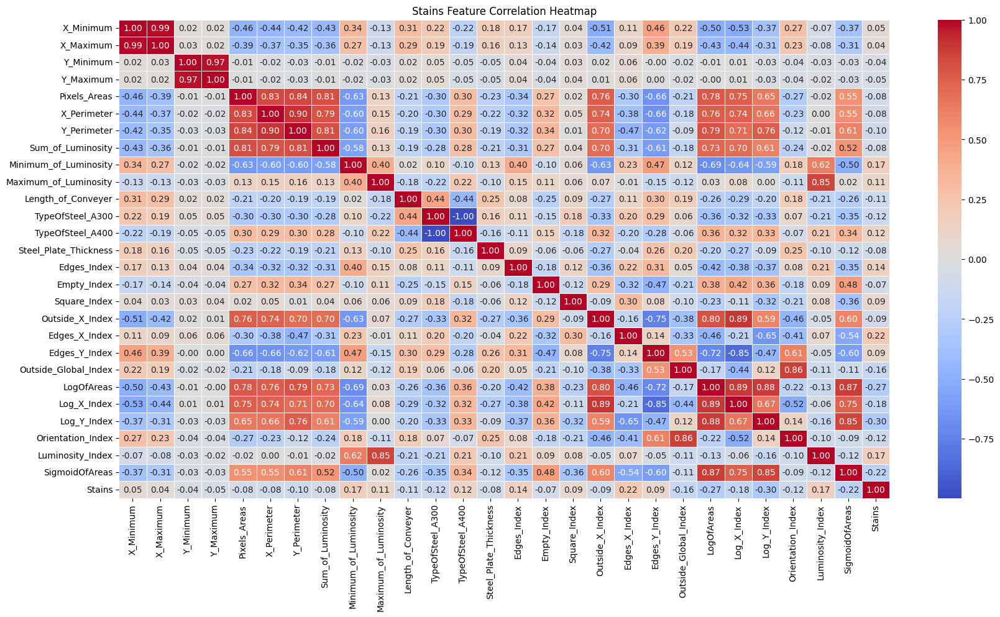

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_s.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Stains Feature Correlation Heatmap")
plt.show()

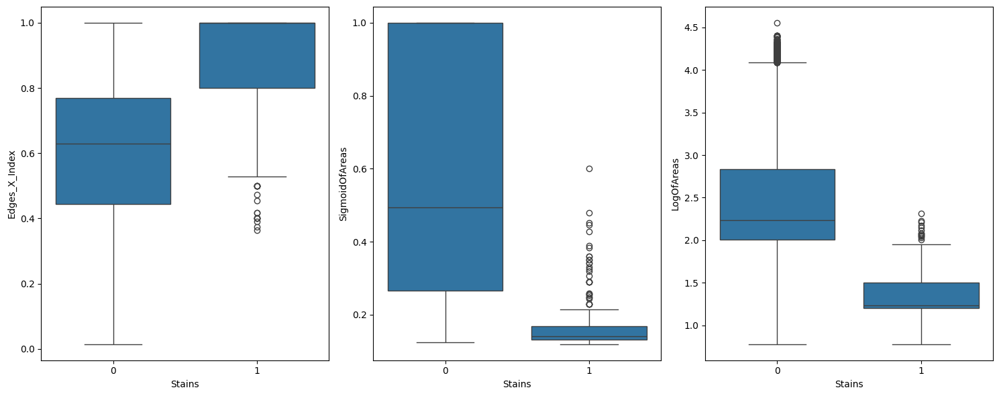

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(131)
sns.boxplot(x=data_s['Stains'], y=data_s['Edges_X_Index'])
plt.subplot(132)
sns.boxplot(x=data_s['Stains'], y=data_s['SigmoidOfAreas'])
plt.subplot(133)
sns.boxplot(x=data_s['Stains'], y=data_s['LogOfAreas'])

plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_s.columns if col != 'Stains']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_s = cap_outliers_by_group(data_s, col, group_col='Stains')

/tmp/ipython-input-70-2875086573.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 506783. 1458128.  600561. ... 1945494.  301492. 1626575.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-70-2875086573.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 838663.     430980.    1436092.     908661.    2344153.    1789337.
  889721.     294036.     313218.     126958.     847976.     728372.
 1620667.    1333079.    3086321.125 1164931.     273912.    1341296.
  396461.    1738114.    1599173.      51952.    3086321.125 1819728.
 1436092.     745380.    1523381.    3086321.125 2613138.    3086321.125
  149070.    1593120.    1458136.    1444009.     888676.     142260.
 1709871.    

In [ ]:
# for col in [col for col in data_s.columns if col != 'Stains']:
#       data_s = outlier_fx_grouped(data_s, col, 'Stains')

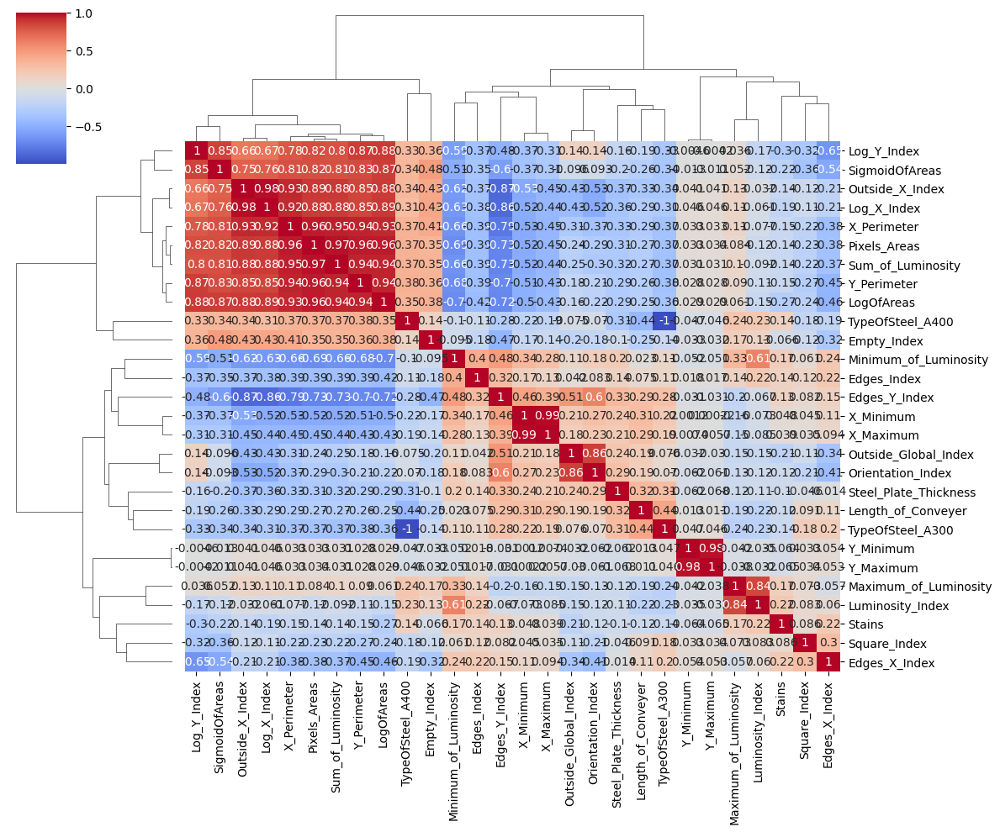

In [ ]:
correlation = data_s.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
features_to_drop = [
    'Y_Minimum',
    'X_Maximum',
    'Sum_of_Luminosity',
    'Pixels_Areas',
    'X_Perimeter',
    'Outside_X_Index'
]

data_s = data_s.drop(columns=features_to_drop)
data_s

,X_Minimum,Y_Maximum,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Stains
9002,921,506794.0,13.0,84.0,111.0,1360,1,0,140,0.6195,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,1458136.0,85.0,88.0,124.0,1358,0,1,40,0.7067,...,0.7813,0.6286,0.0,3.3404,2.1180,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,600841.0,141.5,99.0,125.0,1353,0,1,70,0.0739,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1144070.0,18.0,84.0,118.0,1694,1,0,60,0.1213,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,1814708.0,113.0,49.0,127.0,1356,0,1,40,0.0575,...,0.6914,0.5664,0.0,3.6366,2.1180,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,141.5,36.0,141.0,1400,0,1,40,0.0586,...,0.2119,0.3689,0.0,4.0873,2.1180,2.0086,-0.0553,-0.3499,1.0000,0
11964,1677,1720592.0,31.0,55.0,109.0,1692,1,0,80,0.0071,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.3499,0.4106,0
5390,39,1945637.0,141.5,119.0,141.0,1356,0,1,40,0.0557,...,0.7222,0.4465,0.0,4.0873,2.1180,2.1732,-0.6000,-0.0970,1.0000,0
860,604,301511.0,5.0,120.0,140.0,1358,0,1,50,0.6667,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


In [ ]:
features_d = [col for col in data_s.columns if col != 'Stains']
iso = IsolationForest(contamination=0.01, random_state=42)
data_s['outlier_flag_d'] = iso.fit_predict(data_s[features_d])

In [ ]:
data_s = data_s.loc[(data_s['outlier_flag_d'] == 1), :]
data_s

,X_Minimum,Y_Maximum,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,...,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Stains,outlier_flag_d
9002,921,506794.0,13.0,84.0,111.0,1360,1,0,140,0.6195,...,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0,1
4731,779,1458136.0,85.0,88.0,124.0,1358,0,1,40,0.7067,...,0.6286,0.0,3.3404,2.1180,1.6721,-0.6548,-0.1821,1.0000,0,1
4125,1323,600841.0,141.5,99.0,125.0,1353,0,1,70,0.0739,...,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0,1
1372,1277,1144070.0,18.0,84.0,118.0,1694,1,0,60,0.1213,...,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0,1
984,39,1814708.0,113.0,49.0,127.0,1356,0,1,40,0.0575,...,0.5664,0.0,3.6366,2.1180,1.7708,-0.6546,-0.1382,1.0000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,141.5,36.0,141.0,1400,0,1,40,0.0586,...,0.3689,0.0,4.0873,2.1180,2.0086,-0.0553,-0.3499,1.0000,0,1
11964,1677,1720592.0,31.0,55.0,109.0,1692,1,0,80,0.0071,...,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.3499,0.4106,0,1
5390,39,1945637.0,141.5,119.0,141.0,1356,0,1,40,0.0557,...,0.4465,0.0,4.0873,2.1180,2.1732,-0.6000,-0.0970,1.0000,0,1
860,604,301511.0,5.0,120.0,140.0,1358,0,1,50,0.6667,...,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0,1


In [ ]:
features = [col for col in data_s.columns if (col != 'Stains')]
y = data_s['Stains']

def correlation_vote_filter(X, y, threshold=0.11):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_s[features], y, threshold=0.11)
corr_feat

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipython-input-76-1213169844.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(X[col], y)
/tmp/ipython-input-76-1213169844.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(X[col], y)


['X_Minimum',
 'Y_Maximum',
 'Steel_Plate_Thickness',
 'Empty_Index',
 'Square_Index',
 'outlier_flag_d']

In [ ]:
data_s.drop(columns=corr_feat, inplace=True)
data_s

/tmp/ipython-input-77-1227407369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_s.drop(columns=corr_feat, inplace=True)


,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Edges_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Stains
9002,13.0,84.0,111.0,1360,1,0,0.6195,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,85.0,88.0,124.0,1358,0,1,0.7067,0.7813,0.6286,0.0,3.3404,2.1180,1.6721,-0.6548,-0.1821,1.0000,0
4125,141.5,99.0,125.0,1353,0,1,0.0739,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,18.0,84.0,118.0,1694,1,0,0.1213,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,113.0,49.0,127.0,1356,0,1,0.0575,0.6914,0.5664,0.0,3.6366,2.1180,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,141.5,36.0,141.0,1400,0,1,0.0586,0.2119,0.3689,0.0,4.0873,2.1180,2.0086,-0.0553,-0.3499,1.0000,0
11964,31.0,55.0,109.0,1692,1,0,0.0071,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.3499,0.4106,0
5390,141.5,119.0,141.0,1356,0,1,0.0557,0.7222,0.4465,0.0,4.0873,2.1180,2.1732,-0.6000,-0.0970,1.0000,0
860,5.0,120.0,140.0,1358,0,1,0.6667,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


In [ ]:
X_all = data_s.drop(columns='Stains')
y_all = data_s['Stains']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

clf_all_stains = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_stains.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_stains.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

building tree 1 of 120
building tree 2 of 120
building tree 3 of 120
building tree 4 of 120
building tree 5 of 120
building tree 6 of 120
building tree 7 of 120
building tree 8 of 120
building tree 9 of 120
building tree 10 of 120
building tree 11 of 120
building tree 12 of 120
building tree 13 of 120
building tree 14 of 120
building tree 15 of 120
building tree 16 of 120
building tree 17 of 120
building tree 18 of 120
building tree 19 of 120
building tree 20 of 120
building tree 21 of 120
building tree 22 of 120
building tree 23 of 120
building tree 24 of 120
building tree 25 of 120
building tree 26 of 120
building tree 27 of 120
building tree 28 of 120
building tree 29 of 120
building tree 30 of 120
building tree 31 of 120
building tree 32 of 120
building tree 33 of 120
building tree 34 of 120
building tree 35 of 120
building tree 36 of 120
building tree 37 of 120
building tree 38 of 120
building tree 39 of 120
building tree 40 of 120
building tree 41 of 120
building tree 42 of 120
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s


building tree 56 of 120
building tree 57 of 120
building tree 58 of 120
building tree 59 of 120
building tree 60 of 120
building tree 61 of 120
building tree 62 of 120
building tree 63 of 120
building tree 64 of 120
building tree 65 of 120
building tree 66 of 120
building tree 67 of 120
building tree 68 of 120
building tree 69 of 120
building tree 70 of 120
building tree 71 of 120
building tree 72 of 120
building tree 73 of 120
building tree 74 of 120
building tree 75 of 120
building tree 76 of 120
building tree 77 of 120
building tree 78 of 120
building tree 79 of 120
building tree 80 of 120
building tree 81 of 120
building tree 82 of 120
building tree 83 of 120
building tree 84 of 120
building tree 85 of 120
building tree 86 of 120
building tree 87 of 120
building tree 88 of 120
building tree 89 of 120
building tree 90 of 120
building tree 91 of 120
building tree 92 of 120
building tree 93 of 120
building tree 94 of 120
building tree 95 of 120
building tree 96 of 120
building tree 97

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished


In [ ]:
model_library[3] = clf_all_stains
drop_sublist = ['Y_Minimum','X_Maximum','Sum_of_Luminosity','Pixels_Areas','X_Perimeter','Outside_X_Index',
                'X_Minimum','Y_Maximum','Steel_Plate_Thickness','Empty_Index','Square_Index']
var_drop[3] = drop_sublist

---
## TARGET FEATURE: DIRTINESS DATA

We continue with Target Feature Data Dirtiness. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_d = datrain.copy()
data_d.drop(columns=['Pastry', 'Z_Scratch', 'K_Scatch',
       'Stains', 'Bumps', 'Other_Faults'], inplace=True)
data_d

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Dirtiness
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,0
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,0
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


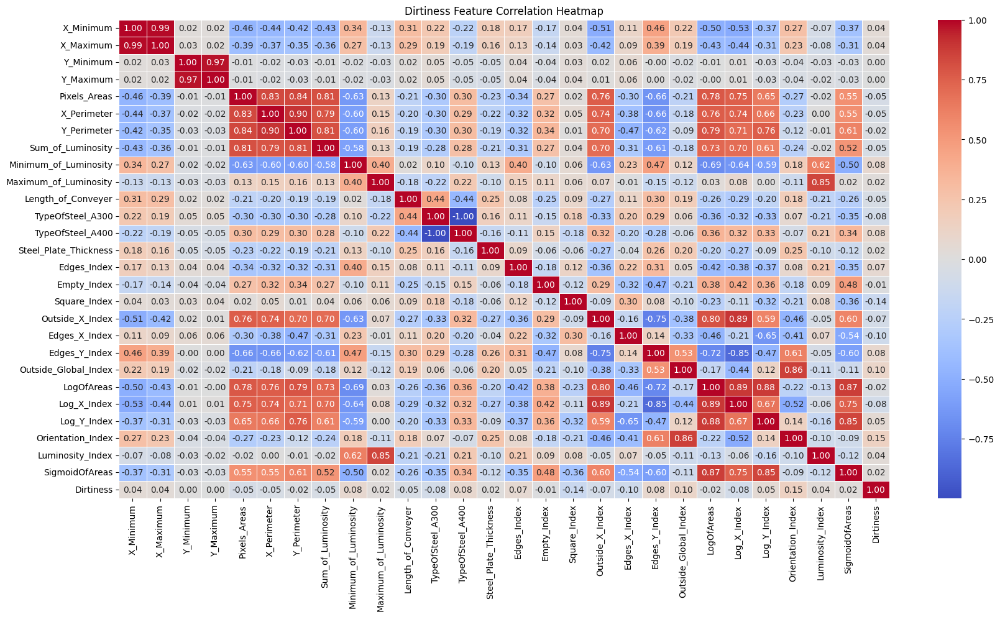

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_d.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Dirtiness Feature Correlation Heatmap")
plt.show()

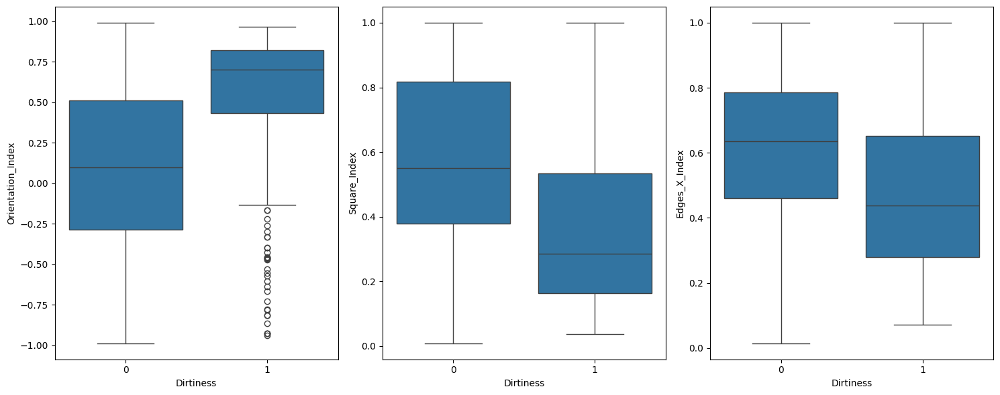

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(131)
sns.boxplot(x=data_d['Dirtiness'], y=data_d['Orientation_Index'])
plt.subplot(132)
sns.boxplot(x=data_d['Dirtiness'], y=data_d['Square_Index'])
plt.subplot(133)
sns.boxplot(x=data_d['Dirtiness'], y=data_d['Edges_X_Index'])

plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_d.columns if col != 'Dirtiness']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_d = cap_outliers_by_group(data_d, col, group_col='Dirtiness')

/tmp/ipython-input-83-834665046.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2488268.     140227.    1658742.     880521.     340581.    2570756.
 1338444.    1747625.     177076.    1881566.    2412964.    1569522.
 1779008.    2058260.    1119116.     939827.     519257.    4338767.375
  519677.    2512899.     435883.     513812.     679386.    2224908.
 1299250.    1759941.     808173.     936743.    1384749.    1349778.
  966898.    4338767.375  419384.     764107.    2229552.    2086004.
  430948.    2887288.     783146.    1484300.    1733458.    2278012.
  899231.    3874199.      91039.     157419.      48235.    2829623.
 2229552.    4338767.375 2089982.    1378585.      96812.    1046618.
 2182058.    1990021.     219220.    2613103.    2401744.    1331507.
  879259.     779104.    4338767.375 1748216.    1148345.    2730163.
  281513.    1068718.     177076.    2158132.    1748216.  

If we only cap this dataset, the correlations are all below 0.2 and giving weak signal, therefore, we're forced to drop all the outliers by IQR methods in order to increase the signal

In [ ]:
# for col in [col for col in data_d.columns if col != 'Dirtiness']:
#       data_d = outlier_fx_grouped(data_d, col, 'Dirtiness')

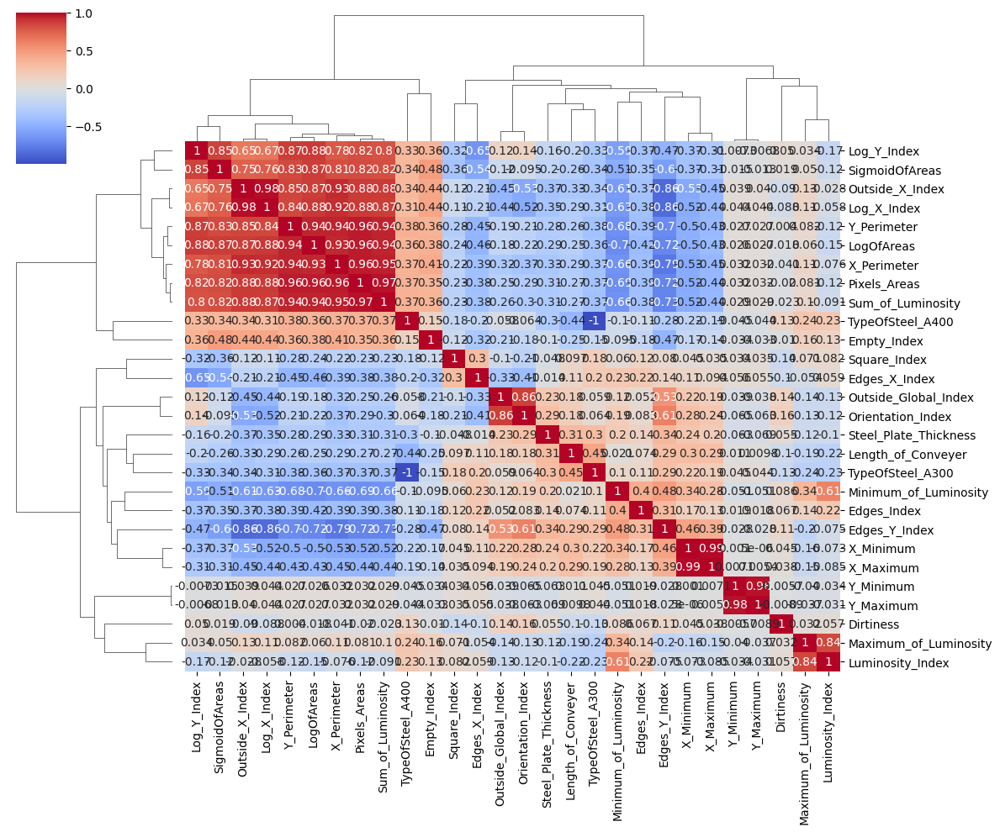

In [ ]:
correlation = data_d.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
# features_to_drop = [
#     'Y_Minimum',
#     'Y_Maximum',
#     'X_Minimum',
#     'Outside_X_Index',
#     'Sum_of_Luminosity',
#     'Log_Y_Index'
# ]

features_to_drop = [
    'Y_Minimum',
    'X_Minimum',
    'Outside_X_Index',
    'Sum_of_Luminosity',
    'Log_Y_Index'
]

data_d = data_d.drop(columns=features_to_drop)
data_d

,X_Maximum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Square_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Dirtiness
9002,934,506794.0,140.0,22.00,13.0,84.0,111.0,1360,1,0,...,0.8571,0.6842,1.0000,0.0,2.1461,1.1461,-0.1429,-0.24920,0.2901,0
4731,842,1458136.0,1496.5,143.75,85.0,88.0,124.0,1358,0,1,...,0.3452,0.7813,0.6286,0.0,3.3404,2.0785,-0.6548,-0.18210,1.0000,0
4125,1333,600841.0,1496.5,143.75,133.0,99.0,125.0,1353,0,1,...,0.2432,0.2000,0.9789,1.0,3.3508,1.0414,0.7568,-0.14350,1.0000,0
1372,1290,1144070.0,194.0,21.00,18.0,84.0,118.0,1694,1,0,...,0.9412,0.8095,0.9444,0.0,2.2878,1.2305,-0.0588,-0.23970,0.4498,0
984,212,1814708.0,1496.5,143.75,113.0,49.0,127.0,1356,0,1,...,0.3454,0.6914,0.5664,0.0,3.6366,2.0785,-0.6546,-0.13820,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,218,1804016.0,1496.5,143.75,133.0,36.0,141.0,1400,0,1,...,0.9448,0.2119,0.3689,0.0,4.1164,2.0785,-0.0553,-0.35505,1.0000,0
11964,1688,1720592.0,196.0,23.00,31.0,55.0,107.5,1692,1,0,...,0.2581,0.4348,1.0000,1.0,2.2923,1.0000,0.7419,-0.35505,0.4106,0
5390,185,1945637.0,1496.5,143.75,133.0,119.0,141.0,1356,0,1,...,0.4000,0.7222,0.4465,0.0,4.0974,2.0785,-0.6000,-0.09700,1.0000,0
860,611,301511.0,16.0,10.00,5.0,120.0,140.0,1358,0,1,...,0.6667,0.8000,1.0000,0.0,1.2041,0.9031,-0.3333,0.00190,0.1353,0


In [ ]:
features_e = [col for col in data_d.columns if col != 'Stains']
iso = IsolationForest(contamination=0.01, random_state=42)
data_d['outlier_flag_e'] = iso.fit_predict(data_d[features_e])

In [ ]:
data_d = data_d.loc[(data_d['outlier_flag_e'] == 1), :]
data_d

,X_Maximum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Dirtiness,outlier_flag_e
9002,934,506794.0,140.0,22.00,13.0,84.0,111.0,1360,1,0,...,0.6842,1.0000,0.0,2.1461,1.1461,-0.1429,-0.24920,0.2901,0,1
4731,842,1458136.0,1496.5,143.75,85.0,88.0,124.0,1358,0,1,...,0.7813,0.6286,0.0,3.3404,2.0785,-0.6548,-0.18210,1.0000,0,1
4125,1333,600841.0,1496.5,143.75,133.0,99.0,125.0,1353,0,1,...,0.2000,0.9789,1.0,3.3508,1.0414,0.7568,-0.14350,1.0000,0,1
1372,1290,1144070.0,194.0,21.00,18.0,84.0,118.0,1694,1,0,...,0.8095,0.9444,0.0,2.2878,1.2305,-0.0588,-0.23970,0.4498,0,1
984,212,1814708.0,1496.5,143.75,113.0,49.0,127.0,1356,0,1,...,0.6914,0.5664,0.0,3.6366,2.0785,-0.6546,-0.13820,1.0000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,218,1804016.0,1496.5,143.75,133.0,36.0,141.0,1400,0,1,...,0.2119,0.3689,0.0,4.1164,2.0785,-0.0553,-0.35505,1.0000,0,1
11964,1688,1720592.0,196.0,23.00,31.0,55.0,107.5,1692,1,0,...,0.4348,1.0000,1.0,2.2923,1.0000,0.7419,-0.35505,0.4106,0,1
5390,185,1945637.0,1496.5,143.75,133.0,119.0,141.0,1356,0,1,...,0.7222,0.4465,0.0,4.0974,2.0785,-0.6000,-0.09700,1.0000,0,1
860,611,301511.0,16.0,10.00,5.0,120.0,140.0,1358,0,1,...,0.8000,1.0000,0.0,1.2041,0.9031,-0.3333,0.00190,0.1353,0,1


In [ ]:
features = [col for col in data_d.columns if (col != 'Dirtiness') & (col != 'Y_Maximum')]
y = data_d['Dirtiness']

def correlation_vote_filter(X, y, threshold):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_d[features], y, 0.06)
corr_feat

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipython-input-89-975697805.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(X[col], y)
/tmp/ipython-input-89-975697805.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(X[col], y)


['X_Maximum',
 'Pixels_Areas',
 'X_Perimeter',
 'Y_Perimeter',
 'Maximum_of_Luminosity',
 'Steel_Plate_Thickness',
 'Empty_Index',
 'LogOfAreas',
 'SigmoidOfAreas',
 'outlier_flag_e']

In [ ]:
data_d.drop(columns=corr_feat, inplace=True)
data_d

/tmp/ipython-input-90-2244050692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_d.drop(columns=corr_feat, inplace=True)


,Y_Maximum,Minimum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Edges_Index,Square_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,Log_X_Index,Orientation_Index,Luminosity_Index,Dirtiness
9002,506794.0,84.0,1360,1,0,0.6195,0.8571,0.6842,1.0000,0.0,1.1461,-0.1429,-0.24920,0
4731,1458136.0,88.0,1358,0,1,0.7067,0.3452,0.7813,0.6286,0.0,2.0785,-0.6548,-0.18210,0
4125,600841.0,99.0,1353,0,1,0.0739,0.2432,0.2000,0.9789,1.0,1.0414,0.7568,-0.14350,0
1372,1144070.0,84.0,1694,1,0,0.1213,0.9412,0.8095,0.9444,0.0,1.2305,-0.0588,-0.23970,0
984,1814708.0,49.0,1356,0,1,0.0575,0.3454,0.6914,0.5664,0.0,2.0785,-0.6546,-0.13820,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1804016.0,36.0,1400,0,1,0.0586,0.9448,0.2119,0.3689,0.0,2.0785,-0.0553,-0.35505,0
11964,1720592.0,55.0,1692,1,0,0.0071,0.2581,0.4348,1.0000,1.0,1.0000,0.7419,-0.35505,0
5390,1945637.0,119.0,1356,0,1,0.0557,0.4000,0.7222,0.4465,0.0,2.0785,-0.6000,-0.09700,0
860,301511.0,120.0,1358,0,1,0.6667,0.6667,0.8000,1.0000,0.0,0.9031,-0.3333,0.00190,0


In [ ]:
X_all = data_d.drop(columns='Dirtiness')
y_all = data_d['Dirtiness']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

clf_all_dirtiness = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_dirtiness.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_dirtiness.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

building tree 1 of 120
building tree 2 of 120
building tree 3 of 120
building tree 4 of 120
building tree 5 of 120
building tree 6 of 120
building tree 7 of 120
building tree 8 of 120
building tree 9 of 120
building tree 10 of 120
building tree 11 of 120
building tree 12 of 120
building tree 13 of 120
building tree 14 of 120
building tree 15 of 120
building tree 16 of 120
building tree 17 of 120
building tree 18 of 120
building tree 19 of 120
building tree 20 of 120
building tree 21 of 120
building tree 22 of 120
building tree 23 of 120
building tree 24 of 120
building tree 25 of 120
building tree 26 of 120
building tree 27 of 120
building tree 28 of 120
building tree 29 of 120
building tree 30 of 120
building tree 31 of 120
building tree 32 of 120
building tree 33 of 120
building tree 34 of 120
building tree 35 of 120
building tree 36 of 120
building tree 37 of 120
building tree 38 of 120
building tree 39 of 120
building tree 40 of 120
building tree 41 of 120
building tree 42 of 120
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s


building tree 55 of 120
building tree 56 of 120
building tree 57 of 120
building tree 58 of 120
building tree 59 of 120
building tree 60 of 120
building tree 61 of 120
building tree 62 of 120
building tree 63 of 120
building tree 64 of 120
building tree 65 of 120
building tree 66 of 120
building tree 67 of 120
building tree 68 of 120
building tree 69 of 120
building tree 70 of 120
building tree 71 of 120
building tree 72 of 120
building tree 73 of 120
building tree 74 of 120
building tree 75 of 120
building tree 76 of 120
building tree 77 of 120
building tree 78 of 120
building tree 79 of 120
building tree 80 of 120
building tree 81 of 120
building tree 82 of 120
building tree 83 of 120
building tree 84 of 120
building tree 85 of 120
building tree 86 of 120
building tree 87 of 120
building tree 88 of 120
building tree 89 of 120
building tree 90 of 120
building tree 91 of 120
building tree 92 of 120
building tree 93 of 120
building tree 94 of 120
building tree 95 of 120
building tree 96

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished


In [ ]:
model_library[4] = clf_all_dirtiness
drop_sublist = ['Y_Minimum','X_Minimum','Outside_X_Index','Sum_of_Luminosity',
                'Log_Y_Index','X_Maximum','Pixels_Areas','X_Perimeter','Y_Perimeter','Maximum_of_Luminosity',
                'Steel_Plate_Thickness','Empty_Index','LogOfAreas','SigmoidOfAreas']
var_drop[4] = drop_sublist

---
## TARGET FEATURE: BUMPS DATA

We continue with Target Feature Bumps. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_bumps = datrain.copy()
data_bumps.drop(columns=['Pastry', 'Z_Scratch', 'K_Scatch',
       'Stains', 'Dirtiness', 'Other_Faults'], inplace=True)
data_bumps

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Bumps
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,0
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,0
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,1
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,0
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,0
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,0
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,0


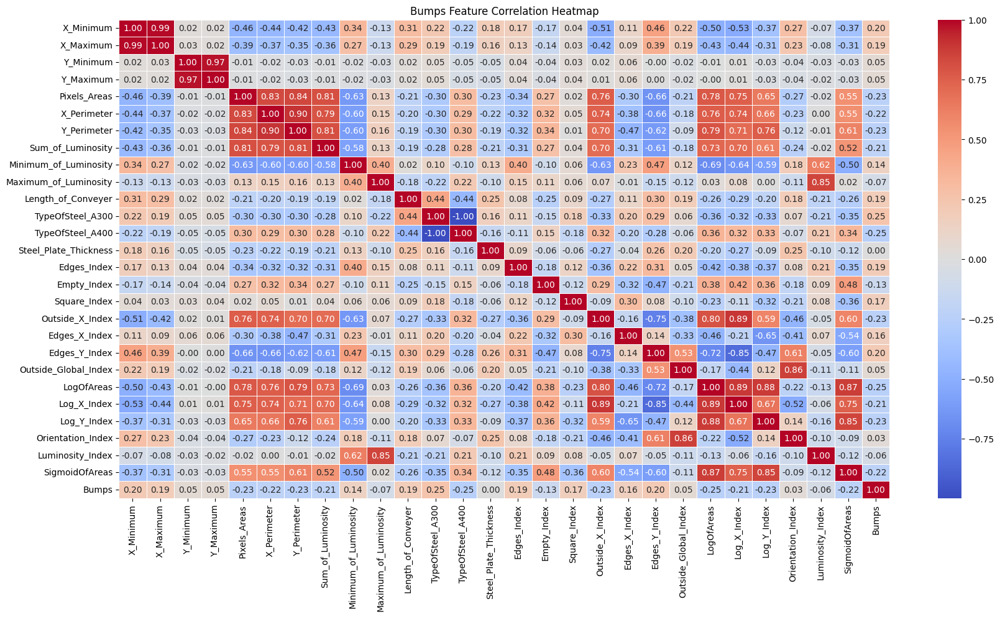

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_bumps.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Bumps Feature Correlation Heatmap")
plt.show()

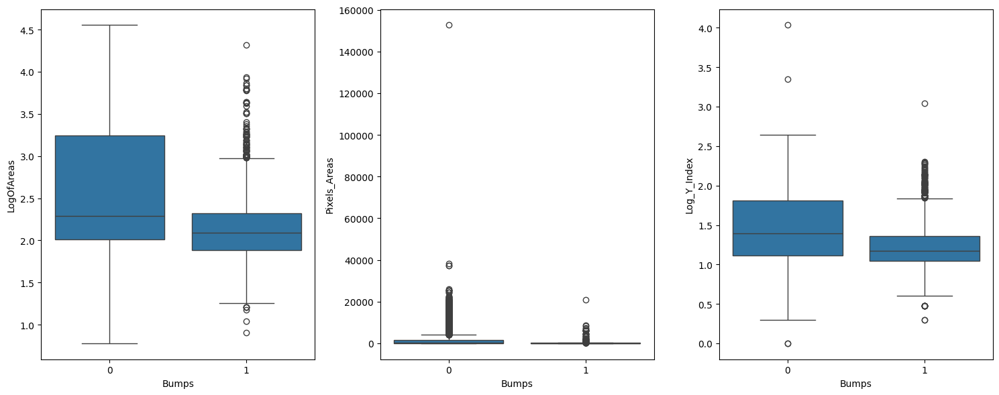

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(131)
sns.boxplot(x=data_bumps['Bumps'], y=data_bumps['LogOfAreas'])
plt.subplot(132)
sns.boxplot(x=data_bumps['Bumps'], y=data_bumps['Pixels_Areas'])
plt.subplot(133)
sns.boxplot(x=data_bumps['Bumps'], y=data_bumps['Log_Y_Index'])

plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_bumps.columns if col != 'Bumps']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_bumps = cap_outliers_by_group(data_bumps, col, group_col='Bumps')

/tmp/ipython-input-96-4143273390.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 506794. 1458136.  600841. ... 1945637.  301511. 1626636.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-96-4143273390.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 140.  2160.  2243.  ... 4229.5   16.  4229.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-96-4143273390.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 22. 173. 165. ... 319.  10. 274.]' has dtype incomp

In [ ]:
# for col in [col for col in data_bumps.columns if col != 'Bumps']:
#       data_bumps = outlier_fx_grouped(data_bumps, col, 'Bumps')

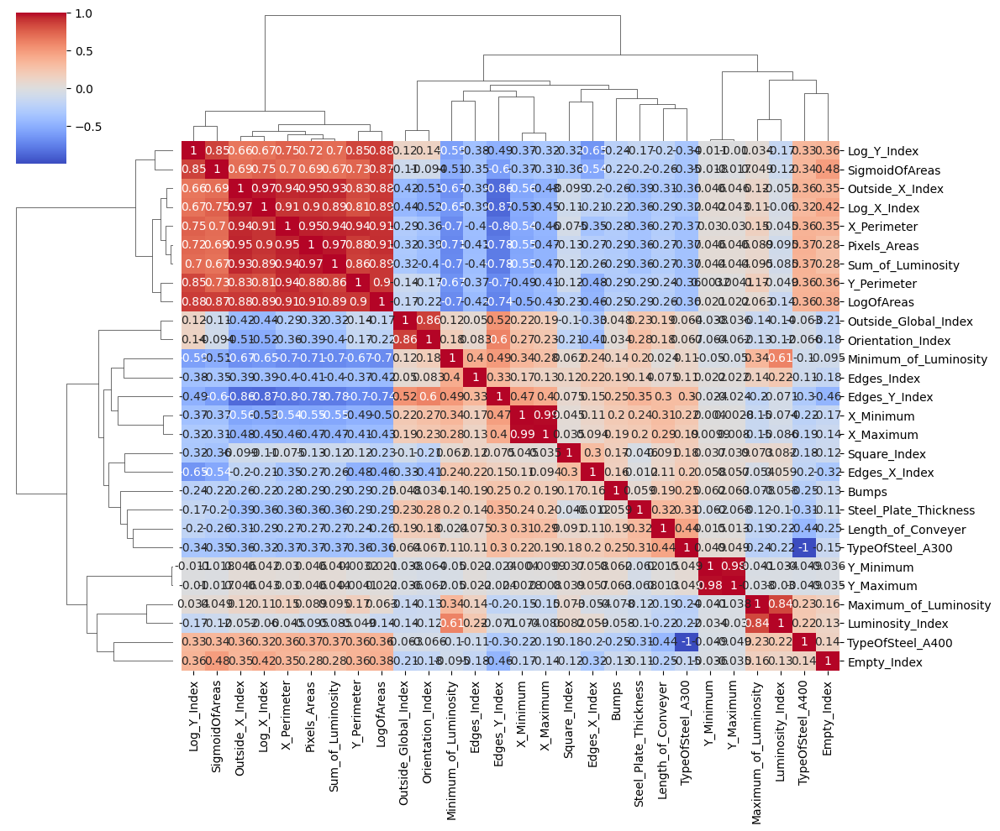

In [ ]:
correlation = data_bumps.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
# features_to_drop = [
#     'Y_Minimum',
#     'X_Maximum',
#     'Sum_of_Luminosity',
#     'LogOfAreas',
#     'Log_X_Index',
#     'Outside_Global_Index',
#     'Orientation_Index'
# ]

features_to_drop = [
    'Y_Minimum',
    'X_Maximum',
    'Sum_of_Luminosity',
    'LogOfAreas',
    'Outside_Global_Index',
    'Orientation_Index'
]

data_bumps = data_bumps.drop(columns=features_to_drop)
data_bumps

,X_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Log_X_Index,Log_Y_Index,Luminosity_Index,SigmoidOfAreas,Bumps
9002,921,506794.0,140.0,22.00,13.0,84.0,111.0,1360,1,0,...,0.3175,0.8571,0.0103,0.6842,1.0000,1.1461,1.1139,-0.249200,0.2901,0
4731,779,1458136.0,2160.0,173.00,85.0,88.0,124.0,1358,0,1,...,0.3864,0.3452,0.0676,0.7813,0.6286,2.1271,1.6721,-0.182100,1.0000,0
4125,1323,600841.0,2243.0,165.00,247.5,99.0,125.0,1353,0,1,...,0.4676,0.2432,0.0081,0.2000,0.9789,1.0414,2.4533,-0.143500,1.0000,0
1372,1277,1144070.0,194.0,21.00,18.0,84.0,118.0,1694,1,0,...,0.2734,0.9412,0.0126,0.8095,0.9444,1.2305,1.2305,-0.239700,0.4498,1
984,39,1814708.0,4229.5,256.00,113.0,49.0,127.0,1356,0,1,...,0.3916,0.3454,0.0676,0.6914,0.5664,2.2330,1.7708,-0.138200,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,4229.5,363.75,247.5,36.0,141.0,1400,0,1,...,0.5180,0.9448,0.0676,0.2119,0.3689,2.2480,2.0086,-0.356925,1.0000,0
11964,1677,1720592.0,196.0,23.00,31.0,55.0,107.5,1692,1,0,...,0.3647,0.2581,0.0059,0.4348,1.0000,1.0000,1.4914,-0.356925,0.4106,0
5390,39,1945637.0,4229.5,319.00,184.0,119.0,141.0,1356,0,1,...,0.4768,0.4000,0.0676,0.7222,0.4465,2.1644,2.1732,-0.097000,1.0000,0
860,604,301511.0,16.0,10.00,5.0,120.0,140.0,1358,0,1,...,0.3400,0.6667,0.0059,0.8000,1.0000,0.9031,0.6021,0.001900,0.1353,0


In [ ]:
features_f = [col for col in data_bumps.columns if col != 'Bumps']
iso = IsolationForest(contamination=0.01, random_state=42)
data_bumps['outlier_flag_f'] = iso.fit_predict(data_bumps[features_f])

In [ ]:
data_bumps = data_bumps.loc[(data_bumps['outlier_flag_f'] == 1), :]
data_bumps

,X_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Log_X_Index,Log_Y_Index,Luminosity_Index,SigmoidOfAreas,Bumps,outlier_flag_f
9002,921,506794.0,140.0,22.00,13.0,84.0,111.0,1360,1,0,...,0.8571,0.0103,0.6842,1.0000,1.1461,1.1139,-0.249200,0.2901,0,1
4731,779,1458136.0,2160.0,173.00,85.0,88.0,124.0,1358,0,1,...,0.3452,0.0676,0.7813,0.6286,2.1271,1.6721,-0.182100,1.0000,0,1
4125,1323,600841.0,2243.0,165.00,247.5,99.0,125.0,1353,0,1,...,0.2432,0.0081,0.2000,0.9789,1.0414,2.4533,-0.143500,1.0000,0,1
1372,1277,1144070.0,194.0,21.00,18.0,84.0,118.0,1694,1,0,...,0.9412,0.0126,0.8095,0.9444,1.2305,1.2305,-0.239700,0.4498,1,1
984,39,1814708.0,4229.5,256.00,113.0,49.0,127.0,1356,0,1,...,0.3454,0.0676,0.6914,0.5664,2.2330,1.7708,-0.138200,1.0000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,4229.5,363.75,247.5,36.0,141.0,1400,0,1,...,0.9448,0.0676,0.2119,0.3689,2.2480,2.0086,-0.356925,1.0000,0,1
11964,1677,1720592.0,196.0,23.00,31.0,55.0,107.5,1692,1,0,...,0.2581,0.0059,0.4348,1.0000,1.0000,1.4914,-0.356925,0.4106,0,1
5390,39,1945637.0,4229.5,319.00,184.0,119.0,141.0,1356,0,1,...,0.4000,0.0676,0.7222,0.4465,2.1644,2.1732,-0.097000,1.0000,0,1
860,604,301511.0,16.0,10.00,5.0,120.0,140.0,1358,0,1,...,0.6667,0.0059,0.8000,1.0000,0.9031,0.6021,0.001900,0.1353,0,1


In [ ]:
features = [col for col in data_bumps.columns if (col != 'Bumps')]
y = data_bumps['Bumps']

def correlation_vote_filter(X, y, threshold):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_bumps[features], y, 0.05)
corr_feat

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipython-input-102-4030983028.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(X[col], y)
/tmp/ipython-input-102-4030983028.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(X[col], y)


['outlier_flag_f']

In [ ]:
data_bumps.drop(columns=corr_feat, inplace=True)
data_bumps

/tmp/ipython-input-103-601269936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bumps.drop(columns=corr_feat, inplace=True)


,X_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Log_X_Index,Log_Y_Index,Luminosity_Index,SigmoidOfAreas,Bumps
9002,921,506794.0,140.0,22.00,13.0,84.0,111.0,1360,1,0,...,0.3175,0.8571,0.0103,0.6842,1.0000,1.1461,1.1139,-0.249200,0.2901,0
4731,779,1458136.0,2160.0,173.00,85.0,88.0,124.0,1358,0,1,...,0.3864,0.3452,0.0676,0.7813,0.6286,2.1271,1.6721,-0.182100,1.0000,0
4125,1323,600841.0,2243.0,165.00,247.5,99.0,125.0,1353,0,1,...,0.4676,0.2432,0.0081,0.2000,0.9789,1.0414,2.4533,-0.143500,1.0000,0
1372,1277,1144070.0,194.0,21.00,18.0,84.0,118.0,1694,1,0,...,0.2734,0.9412,0.0126,0.8095,0.9444,1.2305,1.2305,-0.239700,0.4498,1
984,39,1814708.0,4229.5,256.00,113.0,49.0,127.0,1356,0,1,...,0.3916,0.3454,0.0676,0.6914,0.5664,2.2330,1.7708,-0.138200,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,1804016.0,4229.5,363.75,247.5,36.0,141.0,1400,0,1,...,0.5180,0.9448,0.0676,0.2119,0.3689,2.2480,2.0086,-0.356925,1.0000,0
11964,1677,1720592.0,196.0,23.00,31.0,55.0,107.5,1692,1,0,...,0.3647,0.2581,0.0059,0.4348,1.0000,1.0000,1.4914,-0.356925,0.4106,0
5390,39,1945637.0,4229.5,319.00,184.0,119.0,141.0,1356,0,1,...,0.4768,0.4000,0.0676,0.7222,0.4465,2.1644,2.1732,-0.097000,1.0000,0
860,604,301511.0,16.0,10.00,5.0,120.0,140.0,1358,0,1,...,0.3400,0.6667,0.0059,0.8000,1.0000,0.9031,0.6021,0.001900,0.1353,0


In [ ]:
X_all = data_bumps.drop(columns='Bumps')
y_all = data_bumps['Bumps']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# clf_all = GradientBoostingClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
# clf_all = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_bumps = LGBMClassifier(n_estimators=120, max_depth=25, random_state=42, verbosity=3)
clf_all_bumps.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_bumps.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

[LightGBM] [Info] Number of positive: 3058, number of negative: 9118
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.001988
[LightGBM] [Debug] init for col-wise cost 0.000133 seconds, init for row-wise cost 0.002432 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3666
[LightGBM] [Info] Number of data points in the train set: 12176, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.251150 -> initscore=-1.092489
[LightGBM] [Info] Start training from score -1.092489
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[

In [ ]:
model_library[5] = clf_all_bumps
drop_sublist = ['Y_Minimum','X_Maximum','Sum_of_Luminosity','LogOfAreas','Outside_Global_Index','Orientation_Index']
var_drop[5] = drop_sublist

---
## OTHER FAULTS

We continue with Target Feature Other Faults. Firstly we drop all the target features, and after that we'll do cleaning either by capping or cleaning-whichever that can increase the correlations signal and after that we'll model the Machine Learning and store it inside the bins/dictionaries along with the dropped features for later use.

In [ ]:
data_o = datrain.copy()
data_o.drop(columns=['Pastry', 'Z_Scratch', 'K_Scatch',
       'Stains', 'Dirtiness', 'Bumps'], inplace=True)
data_o

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Other_Faults
9002,921,934,506783,506794,140,22,13,14742,84,111,...,0.6842,1.0000,0.0,2.1461,1.1461,1.1139,-0.1429,-0.2492,0.2901,1
4731,779,842,1458128,1458136,2160,173,85,275539,88,124,...,0.7813,0.6286,0.0,3.3404,2.1271,1.6721,-0.6548,-0.1821,1.0000,1
4125,1323,1333,600561,600841,2243,165,285,262543,99,125,...,0.2000,0.9789,1.0,3.3508,1.0414,2.4533,0.7568,-0.1435,1.0000,0
1372,1277,1290,1144047,1144070,194,21,18,19202,84,118,...,0.8095,0.9444,0.0,2.2878,1.2305,1.2305,-0.0588,-0.2397,0.4498,0
984,39,212,1814642,1814708,4788,256,113,516343,49,127,...,0.6914,0.5664,0.0,3.6366,2.2330,1.7708,-0.6546,-0.1382,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1803992,1804016,16686,805,503,2013557,36,141,...,0.2119,0.3689,0.0,4.2296,2.2480,2.0086,-0.0553,-0.3805,1.0000,1
11964,1677,1688,1720569,1720592,196,23,31,12221,55,94,...,0.4348,1.0000,1.0,2.2923,1.0000,1.4914,0.7419,-0.4188,0.4106,1
5390,39,185,1945494,1945637,12012,319,184,1381722,119,141,...,0.7222,0.4465,0.0,4.0974,2.1644,2.1732,-0.6000,-0.0970,1.0000,0
860,604,611,301492,301511,16,10,5,2034,120,140,...,0.8000,1.0000,0.0,1.2041,0.9031,0.6021,-0.3333,0.0019,0.1353,1


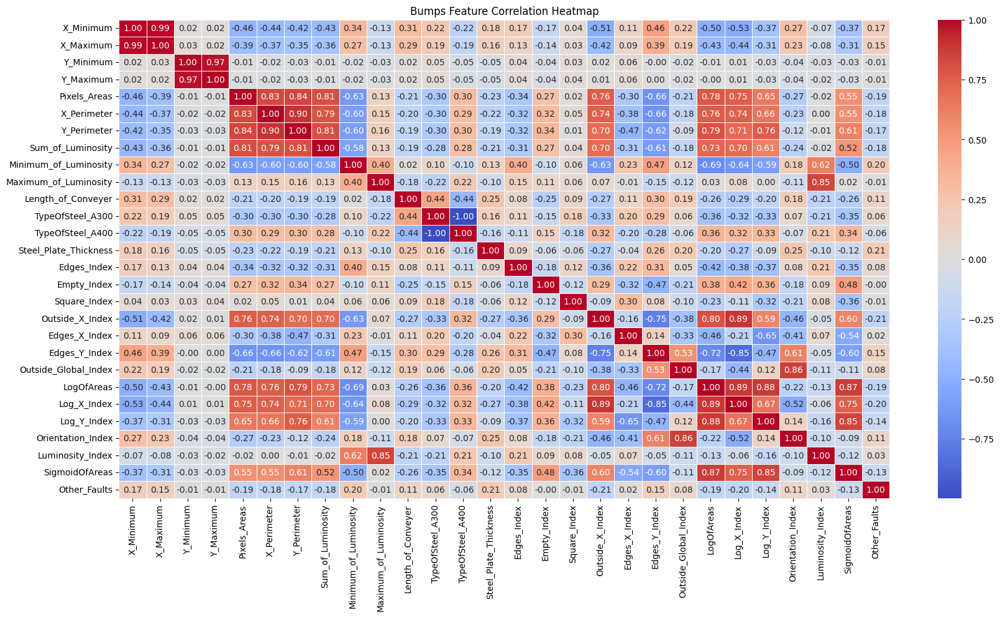

In [ ]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data_o.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Bumps Feature Correlation Heatmap")
plt.show()

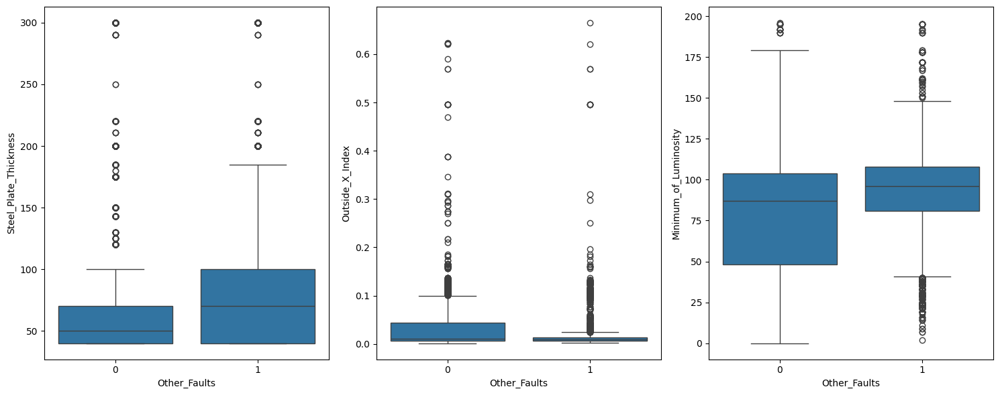

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(131)
sns.boxplot(x=data_o['Other_Faults'], y=data_o['Steel_Plate_Thickness'])
plt.subplot(132)
sns.boxplot(x=data_o['Other_Faults'], y=data_o['Outside_X_Index'])
plt.subplot(133)
sns.boxplot(x=data_o['Other_Faults'], y=data_o['Minimum_of_Luminosity'])

plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data_o.columns if col != 'Other_Faults']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data_o = cap_outliers_by_group(data_o, col, group_col='Other_Faults')

/tmp/ipython-input-109-4270246868.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 600841. 1144070. 1814708. ... 3996170. 1945637. 1626636.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-109-4270246868.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2243.   194.  4788.  ...  220.  4918.5 4918.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)
/tmp/ipython-input-109-4270246868.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[165.  21. 256. ...  30. 319. 274.]' has dtype inc

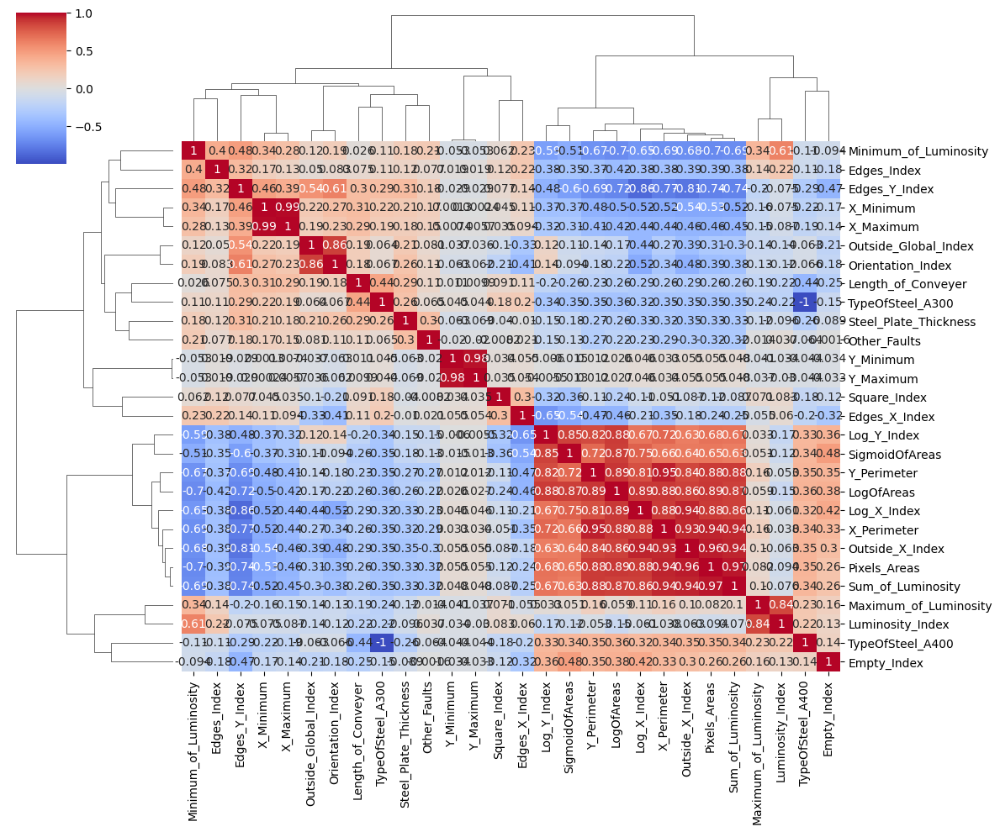

In [ ]:
correlation = data_o.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

In [ ]:
features_to_drop = [
    'Sum_of_Luminosity',
    'X_Perimeter',
    'Y_Minimum'
]

data_o = data_o.drop(columns=features_to_drop)
data_o

,X_Minimum,X_Maximum,Y_Maximum,Pixels_Areas,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Other_Faults
9002,921,934,506794.0,140.0,13,84.0,111.0,1360,1,0,...,0.6842,1.0000,0.0,2.14610,1.1461,1.1139,-0.1429,-0.24920,0.2901,1
4731,779,842,1458136.0,570.0,68,88.0,124.0,1358,0,1,...,0.7813,0.6286,0.0,3.22765,1.8212,1.6721,-0.6548,-0.18210,1.0000,1
4125,1323,1333,600841.0,2243.0,254,99.0,125.0,1353,0,1,...,0.2000,0.9789,1.0,3.35080,1.0414,2.4533,0.7568,-0.14350,1.0000,0
1372,1277,1290,1144070.0,194.0,18,84.0,118.0,1694,1,0,...,0.8095,0.9444,0.0,2.28780,1.2305,1.2305,-0.0588,-0.23970,0.4498,0
984,39,212,1814708.0,4788.0,113,49.0,127.0,1356,0,1,...,0.6914,0.5664,0.0,3.63660,2.2330,1.7708,-0.6546,-0.13820,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1804016.0,570.0,68,40.5,141.0,1400,0,1,...,0.2119,0.5455,0.0,3.22765,1.8212,2.0086,-0.0553,-0.38050,1.0000,1
11964,1677,1688,1720592.0,196.0,31,55.0,109.0,1692,1,0,...,0.4348,1.0000,1.0,2.29230,1.0000,1.4914,0.7419,-0.40235,0.4106,1
5390,39,185,1945637.0,4918.5,184,119.0,141.0,1356,0,1,...,0.7222,0.4465,0.0,4.09740,2.1644,2.1732,-0.6000,-0.09700,1.0000,0
860,604,611,301511.0,16.0,5,120.0,140.0,1358,0,1,...,0.8000,1.0000,0.0,1.20410,0.9031,0.6021,-0.3333,0.00190,0.1353,1


In [ ]:
features_g = [col for col in data_o.columns if col != 'Other_Faults']
iso = IsolationForest(contamination=0.01, random_state=42)
data_o['outlier_flag_g'] = iso.fit_predict(data_o[features_g])

In [ ]:
data_o = data_o.loc[(data_o['outlier_flag_g'] == 1), :]
data_o

,X_Minimum,X_Maximum,Y_Maximum,Pixels_Areas,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Other_Faults,outlier_flag_g
9002,921,934,506794.0,140.0,13,84.0,111.0,1360,1,0,...,1.0000,0.0,2.14610,1.1461,1.1139,-0.1429,-0.24920,0.2901,1,1
4731,779,842,1458136.0,570.0,68,88.0,124.0,1358,0,1,...,0.6286,0.0,3.22765,1.8212,1.6721,-0.6548,-0.18210,1.0000,1,1
4125,1323,1333,600841.0,2243.0,254,99.0,125.0,1353,0,1,...,0.9789,1.0,3.35080,1.0414,2.4533,0.7568,-0.14350,1.0000,0,1
1372,1277,1290,1144070.0,194.0,18,84.0,118.0,1694,1,0,...,0.9444,0.0,2.28780,1.2305,1.2305,-0.0588,-0.23970,0.4498,0,1
984,39,212,1814708.0,4788.0,113,49.0,127.0,1356,0,1,...,0.5664,0.0,3.63660,2.2330,1.7708,-0.6546,-0.13820,1.0000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1804016.0,570.0,68,40.5,141.0,1400,0,1,...,0.5455,0.0,3.22765,1.8212,2.0086,-0.0553,-0.38050,1.0000,1,1
11964,1677,1688,1720592.0,196.0,31,55.0,109.0,1692,1,0,...,1.0000,1.0,2.29230,1.0000,1.4914,0.7419,-0.40235,0.4106,1,1
5390,39,185,1945637.0,4918.5,184,119.0,141.0,1356,0,1,...,0.4465,0.0,4.09740,2.1644,2.1732,-0.6000,-0.09700,1.0000,0,1
860,604,611,301511.0,16.0,5,120.0,140.0,1358,0,1,...,1.0000,0.0,1.20410,0.9031,0.6021,-0.3333,0.00190,0.1353,1,1


In [ ]:
features = [col for col in data_o.columns if (col != 'Other_Faults')]
y = data_o['Other_Faults']

def correlation_vote_filter(X, y, threshold):
    # results = []
    cols_to_drop = []

    for col in X.select_dtypes(include='number').columns:
        try:
            pb, _ = pointbiserialr(X[col], y)
        except:
            pb = np.nan

        try:
            pr, _ = pearsonr(X[col], y)
        except:
            pr = np.nan

        try:
            sp, _ = spearmanr(X[col], y)
        except:
            sp = np.nan

        # Voting condition
        low_corr = all([
            abs(corr) <= threshold
            for corr in [pb, pr, sp]
            if not np.isnan(corr)
        ])

        if low_corr:
            cols_to_drop.append(col)

        # results.append({
        #     'feature': col,
        #     'point_biserial': pb,
        #     'pearson': pr,
        #     'spearman': sp,
        #     'drop?': low_corr
        # })

    # corr_df = pd.DataFrame(results)
    return cols_to_drop

corr_feat = correlation_vote_filter(data_o[features], y, 0.005)
corr_feat

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipython-input-114-4039408901.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(X[col], y)
/tmp/ipython-input-114-4039408901.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(X[col], y)


['outlier_flag_g']

In [ ]:
data_o.drop(columns=corr_feat, inplace=True)
data_o

/tmp/ipython-input-115-852617159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_o.drop(columns=corr_feat, inplace=True)


,X_Minimum,X_Maximum,Y_Maximum,Pixels_Areas,Y_Perimeter,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Other_Faults
9002,921,934,506794.0,140.0,13,84.0,111.0,1360,1,0,...,0.6842,1.0000,0.0,2.14610,1.1461,1.1139,-0.1429,-0.24920,0.2901,1
4731,779,842,1458136.0,570.0,68,88.0,124.0,1358,0,1,...,0.7813,0.6286,0.0,3.22765,1.8212,1.6721,-0.6548,-0.18210,1.0000,1
4125,1323,1333,600841.0,2243.0,254,99.0,125.0,1353,0,1,...,0.2000,0.9789,1.0,3.35080,1.0414,2.4533,0.7568,-0.14350,1.0000,0
1372,1277,1290,1144070.0,194.0,18,84.0,118.0,1694,1,0,...,0.8095,0.9444,0.0,2.28780,1.2305,1.2305,-0.0588,-0.23970,0.4498,0
984,39,212,1814708.0,4788.0,113,49.0,127.0,1356,0,1,...,0.6914,0.5664,0.0,3.63660,2.2330,1.7708,-0.6546,-0.13820,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,41,218,1804016.0,570.0,68,40.5,141.0,1400,0,1,...,0.2119,0.5455,0.0,3.22765,1.8212,2.0086,-0.0553,-0.38050,1.0000,1
11964,1677,1688,1720592.0,196.0,31,55.0,109.0,1692,1,0,...,0.4348,1.0000,1.0,2.29230,1.0000,1.4914,0.7419,-0.40235,0.4106,1
5390,39,185,1945637.0,4918.5,184,119.0,141.0,1356,0,1,...,0.7222,0.4465,0.0,4.09740,2.1644,2.1732,-0.6000,-0.09700,1.0000,0
860,604,611,301511.0,16.0,5,120.0,140.0,1358,0,1,...,0.8000,1.0000,0.0,1.20410,0.9031,0.6021,-0.3333,0.00190,0.1353,1


In [ ]:
X_all = data_o.drop(columns='Other_Faults')
y_all = data_o['Other_Faults']

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# clf_all = GradientBoostingClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
# clf_all = RandomForestClassifier(n_estimators=120, max_depth=25, random_state=42, verbose=2)
clf_all_others = LGBMClassifier(n_estimators=120, max_depth=25, random_state=42, verbosity=3)
clf_all_others.fit(X_train_all, y_train_all)

y_pred_proba_all = clf_all_others.predict_proba(X_val_all)[:, 1]
roc_all = roc_auc_score(y_val_all, y_pred_proba_all)

print(f"ROC AUC (All Data): {roc_all:.2f}")

[LightGBM] [Info] Number of positive: 4127, number of negative: 8049
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.020450
[LightGBM] [Debug] init for col-wise cost 0.000007 seconds, init for row-wise cost 0.002524 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 4232
[LightGBM] [Info] Number of data points in the train set: 12176, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.338945 -> initscore=-0.667997
[LightGBM] [Info] Start training from score -0.667997
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Train

In [ ]:
model_library[6] = clf_all_others
drop_sublist = ['Sum_of_Luminosity','X_Perimeter','Y_Minimum']
var_drop[6] = drop_sublist

---
## PIPELINE AND ML TESTING

After we modelled the Machine learning and stored the dropped features, we will use them to predict the probabilites of True values on each test data. After that we will combine it into one DataFrame to calculate the AUC ROC score.

In [ ]:
model_library

{0: RandomForestClassifier(max_depth=25, n_estimators=120, random_state=42,
                        verbose=2),
 1: RandomForestClassifier(max_depth=25, n_estimators=120, random_state=42,
                        verbose=2),
 2: RandomForestClassifier(max_depth=25, n_estimators=120, random_state=42,
                        verbose=2),
 3: RandomForestClassifier(max_depth=25, n_estimators=120, random_state=42,
                        verbose=2),
 4: RandomForestClassifier(max_depth=25, n_estimators=120, random_state=42,
                        verbose=2),
 5: LGBMClassifier(max_depth=25, n_estimators=120, random_state=42, verbosity=3),
 6: LGBMClassifier(max_depth=25, n_estimators=120, random_state=42, verbosity=3)}

In [ ]:
var_drop

{0: ['X_Maximum',
  'X_Perimeter',
  'Sum_of_Luminosity',
  'Maximum_of_Luminosity',
  'SigmoidOfAreas',
  'Log_X_Index',
  'Edges_X_Index',
  'Y_Perimeter',
  'Y_Minimum',
  'Minimum_of_Luminosity',
  'TypeOfSteel_A300',
  'TypeOfSteel_A400',
  'Edges_Index'],
 1: ['Y_Minimum',
  'Y_Perimeter',
  'X_Minimum',
  'Log_X_Index',
  'Outside_Global_Index',
  'Luminosity_Index',
  'Log_Y_Index',
  'SigmoidOfAreas',
  'Y_Maximum',
  'Square_Index'],
 2: ['Outside_X_Index',
  'LogOfAreas',
  'Sum_of_Luminosity',
  'Y_Perimeter',
  'Y_Minimum',
  'X_Maximum',
  'Outside_Global_Index',
  'Pixels_Areas',
  'Y_Maximum',
  'Maximum_of_Luminosity',
  'Length_of_Conveyer',
  'TypeOfSteel_A300',
  'TypeOfSteel_A400',
  'Empty_Index',
  'Square_Index',
  'Edges_X_Index',
  'Luminosity_Index'],
 3: ['Y_Minimum',
  'X_Maximum',
  'Sum_of_Luminosity',
  'Pixels_Areas',
  'X_Perimeter',
  'Outside_X_Index',
  'X_Minimum',
  'Y_Maximum',
  'Steel_Plate_Thickness',
  'Empty_Index',
  'Square_Index'],
 4: ['

In [ ]:
# We will recall the models inside the bins and dropped the features based on their sequence
# then we'll predict the probabilities of the test data. After that we'll insert it into one DataFrame

df_result = {}
datest_valid = datest.drop(columns=['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'])
datest_valid.reset_index(drop=True, inplace=True)

for i in range(7):
  substage = datest_valid.drop(columns=var_drop[i])
  y_pred_sub = model_library[i].predict_proba(substage)[:, 1]
  df_result[i] = y_pred_sub
  # print(f'substage data: {substage.columns}')

df_result

0
1
2
3
4
5


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.0s finished


6


{0: array([0.95      , 0.        , 0.4       , ..., 0.33333076, 0.36304466,
        0.        ]),
 1: array([0., 0., 0., ..., 0., 0., 0.]),
 2: array([0.        , 0.55833333, 0.29166667, ..., 0.        , 0.        ,
        1.        ]),
 3: array([0., 0., 0., ..., 0., 0., 0.]),
 4: array([0.12617794, 0.        , 0.        , ..., 0.05833333, 0.01666667,
        0.        ]),
 5: array([2.06889332e-01, 7.79188743e-05, 9.79442855e-04, ...,
        6.44286156e-01, 4.05224848e-01, 7.91093269e-05]),
 6: array([9.97162309e-01, 1.65547785e-04, 9.91975530e-01, ...,
        3.21832918e-01, 3.15234637e-01, 2.05835613e-04])}

In [ ]:
# We put the True (1) probabilities of each features into one DataFrame and put the labels on each data

df_summary = pd.DataFrame(df_result)
datest_2 = datest.copy()
datest.reset_index(drop=True, inplace=True)

result_real = []
result_pred = []
for i in range(len(datest)):
  if datest['Pastry'][i] == 1:
    result_real.append(0)
  elif datest['Z_Scratch'][i] == 1:
    result_real.append(1)
  elif datest['K_Scatch'][i] == 1:
    result_real.append(2)
  elif datest['Stains'][i] == 1:
    result_real.append(3)
  elif datest['Dirtiness'][i] == 1:
    result_real.append(4)
  elif datest['Bumps'][i] == 1:
    result_real.append(5)
  elif datest['Other_Faults'][i] == 1:
    result_real.append(6)
  else:
    result_real.append(7)

df_summary['result_real'] = result_real

for i in datest.index:
  pred_result = df_summary.iloc[i, :7].idxmax()
  result_pred.append(int(pred_result))

df_summary['result_pred'] = result_pred
df_summary

,0,1,2,3,4,5,6,result_real,result_pred
0,0.950000,0.000000,0.000000,0.000,0.126178,0.206889,0.997162,6,6
1,0.000000,0.000000,0.558333,0.000,0.000000,0.000078,0.000166,2,2
2,0.400000,0.000000,0.291667,0.000,0.000000,0.000979,0.991976,6,6
3,0.008333,0.000000,0.000000,0.000,0.000000,0.437574,0.331252,6,5
4,0.110098,0.000000,0.000000,0.000,0.158333,0.506214,0.295983,6,5
...,...,...,...,...,...,...,...,...,...
3839,0.000000,0.483333,0.291667,0.000,0.016667,0.000584,0.001815,1,1
3840,0.000000,0.000000,0.000000,0.025,0.000000,0.488265,0.441101,5,5
3841,0.333331,0.000000,0.000000,0.000,0.058333,0.644286,0.321833,5,5
3842,0.363045,0.000000,0.000000,0.000,0.016667,0.405225,0.315235,5,5


In [ ]:
# Finally we do the AUC ROC test on the predicted data

# Define your true labels and predicted probabilities
y_true_final = df_summary['result_real']
y_proba_final = df_summary[[0, 1, 2, 3, 4, 5, 6]]  # class probabilities

# Binarize the true labels for ROC AUC calculation
y_true_bin = label_binarize(y_true_final, classes=[0, 1, 2, 3, 4, 5, 6])

# Calculate ROC AUC score (macro average)
auc_score = roc_auc_score(y_true_bin, y_proba_final, average='macro', multi_class='ovr')

print(f"Multiclass ROC AUC Score (macro): {auc_score:.2f}")

Multiclass ROC AUC Score (macro): 0.83


CONCLUSSION: We have made a machine learning model with One vs Rest methods on the feature with ROC AUC score 0.83. This model might be able to be improved by exploring the correlations feature again.